Sol Levante Dataset
        ↓
Dataset Validation
        ↓
Storyboard / Animatic / Final Preprocessing
        ↓
CLIP Feature Extraction
        ↓
Cross-Modal Matching
        ↓
Sequence-aware Alignment
        ↓
Evidence Chain Construction
        ↓
Measurement
        ↓
Calibration / Interpretation
        ↓
Coherence Score + Confidence
        ↓
Corrupted Evidence Evaluation
        ↓
JSON Input / Output Interface
         ↓
Human Verification

# 1. 数据集完整性检查

本阶段首先检查 Sol Levante 数据集中三个核心 Evidence Source 是否能够正常读取，包括 Storyboard PDF、Animatic Video 和 Final Video。同时统计 PDF 页数、视频帧数、帧率、分辨率和时长，为后续数据预处理提供基础信息

In [2]:
#检查路径
from pathlib import Path

SOL_ROOT = Path.home() / "Desktop" / "SolLevante"

print("Sol Levante 路径:", SOL_ROOT)
print("是否存在:", SOL_ROOT.exists())

for item in SOL_ROOT.iterdir():
    print("-", item.name)

Sol Levante 路径: /Users/jank/Desktop/SolLevante
是否存在: True
- .DS_Store
- sdr
- working_assets_manifest.json
- bundle.json
- working_assets
- test_evidence.json
- outputs


In [4]:
#检查三个核心文件是否存在
from pathlib import Path

SOL_ROOT = Path.home() / "Desktop" / "SolLevante"

STORYBOARD_PATH = SOL_ROOT / "working_assets" / "SolLevante_Storyboard.pdf"
ANIMATIC_PATH = SOL_ROOT / "working_assets" / "SolLevante_Animatics_ver1_H264.mov"
FINAL_PATH = SOL_ROOT / "sdr" / "SolLevante_SDR_UHD_24fps.mov"

print("Storyboard:")
print(STORYBOARD_PATH)
print("存在:", STORYBOARD_PATH.exists())
print()

print("Animatic:")
print(ANIMATIC_PATH)
print("存在:", ANIMATIC_PATH.exists())
print()

print("Final:")
print(FINAL_PATH)
print("存在:", FINAL_PATH.exists())

Storyboard:
/Users/jank/Desktop/SolLevante/working_assets/SolLevante_Storyboard.pdf
存在: True

Animatic:
/Users/jank/Desktop/SolLevante/working_assets/SolLevante_Animatics_ver1_H264.mov
存在: True

Final:
/Users/jank/Desktop/SolLevante/sdr/SolLevante_SDR_UHD_24fps.mov
存在: True


In [6]:
import sys

print("当前 Jupyter 使用的 Python:")
print(sys.executable)

!{sys.executable} -m pip install opencv-python

当前 Jupyter 使用的 Python:
/opt/anaconda3/envs/ml_a2/bin/python


In [8]:
#检查三个核心文件是否完整、是否能正常读取。
from pathlib import Path
import os
import cv2

SOL_ROOT = Path.home() / "Desktop" / "SolLevante"

STORYBOARD_PATH = SOL_ROOT / "working_assets" / "SolLevante_Storyboard.pdf"
ANIMATIC_PATH = SOL_ROOT / "working_assets" / "SolLevante_Animatics_ver1_H264.mov"
FINAL_PATH = SOL_ROOT / "sdr" / "SolLevante_SDR_UHD_24fps.mov"


def file_size_gb(path):
    if path.exists():
        return path.stat().st_size / (1024 ** 3)
    return None


print("=== File Size Check ===")

print(f"Storyboard: {file_size_gb(STORYBOARD_PATH):.3f} GB")
print(f"Animatic:   {file_size_gb(ANIMATIC_PATH):.3f} GB")
print(f"Final:      {file_size_gb(FINAL_PATH):.3f} GB")

=== File Size Check ===
Storyboard: 0.076 GB
Animatic:   0.313 GB
Final:      15.029 GB


In [10]:
def inspect_video(video_path, name):
    print(f"\n=== {name} ===")
    print("Path:", video_path)
    print("Exists:", video_path.exists())

    cap = cv2.VideoCapture(str(video_path))

    print("Opened:", cap.isOpened())

    if not cap.isOpened():
        print("ERROR: 无法打开视频")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = total_frames / fps if fps > 0 else 0

    print("Frames:", total_frames)
    print("FPS:", fps)
    print("Resolution:", width, "x", height)
    print("Duration:", round(duration, 2), "seconds")
    print("Duration:", round(duration / 60, 2), "minutes")

    cap.release()


inspect_video(ANIMATIC_PATH, "Animatic")
inspect_video(FINAL_PATH, "Final")


=== Animatic ===
Path: /Users/jank/Desktop/SolLevante/working_assets/SolLevante_Animatics_ver1_H264.mov
Exists: True
Opened: True
Frames: 3890
FPS: 23.976023976023978
Resolution: 1920 x 1080
Duration: 162.25 seconds
Duration: 2.7 minutes

=== Final ===
Path: /Users/jank/Desktop/SolLevante/sdr/SolLevante_SDR_UHD_24fps.mov
Exists: True
Opened: True
Frames: 6314
FPS: 24.0
Resolution: 3840 x 2160
Duration: 263.08 seconds
Duration: 4.38 minutes


In [12]:
import sys
!{sys.executable} -m pip install pymupdf

In [14]:
import fitz

pdf = fitz.open(STORYBOARD_PATH)

print("Storyboard PDF 打开成功")
print("页数:", len(pdf))

pdf.close()

Storyboard PDF 打开成功
页数: 48


# 2. 数据预处理 

## 2.1 Storyboard 预处理

In [18]:
from pathlib import Path

OUTPUT_ROOT = SOL_ROOT / "outputs"

STORYBOARD_OUTPUT = OUTPUT_ROOT / "storyboard_pages"
ANIMATIC_OUTPUT = OUTPUT_ROOT / "animatic"
FINAL_OUTPUT = OUTPUT_ROOT / "final"

for folder in [
    OUTPUT_ROOT,
    STORYBOARD_OUTPUT,
    ANIMATIC_OUTPUT,
    FINAL_OUTPUT
]:
    folder.mkdir(parents=True, exist_ok=True)

print("输出目录创建完成：")

for folder in [
    OUTPUT_ROOT,
    STORYBOARD_OUTPUT,
    ANIMATIC_OUTPUT,
    FINAL_OUTPUT
]:
    print("-", folder)

输出目录创建完成：
- /Users/jank/Desktop/SolLevante/outputs
- /Users/jank/Desktop/SolLevante/outputs/storyboard_pages
- /Users/jank/Desktop/SolLevante/outputs/animatic
- /Users/jank/Desktop/SolLevante/outputs/final


In [20]:
#把 48 页 PDF 转成 48 张高清 PNG
import pymupdf

pdf = pymupdf.open(STORYBOARD_PATH)

print("Storyboard 页数:", len(pdf))

for page_index in range(len(pdf)):
    
    page = pdf[page_index]

    # 2倍分辨率，方便后面识别 storyboard panels
    matrix = pymupdf.Matrix(2, 2)

    pix = page.get_pixmap(
        matrix=matrix,
        alpha=False
    )

    output_path = (
        STORYBOARD_OUTPUT /
        f"storyboard_page_{page_index + 1:03d}.png"
    )

    pix.save(str(output_path))

pdf.close()

print("Storyboard 页面提取完成")
print("保存目录:", STORYBOARD_OUTPUT)

Storyboard 页数: 48
Storyboard 页面提取完成
保存目录: /Users/jank/Desktop/SolLevante/outputs/storyboard_pages


In [21]:
#检查有没有真的生成 48 张
storyboard_pages = sorted(
    STORYBOARD_OUTPUT.glob("storyboard_page_*.png")
)

print("生成图片数量:", len(storyboard_pages))

print("\n前 5 个文件：")

for path in storyboard_pages[:5]:
    print(path.name)

生成图片数量: 48

前 5 个文件：
storyboard_page_001.png
storyboard_page_002.png
storyboard_page_003.png
storyboard_page_004.png
storyboard_page_005.png


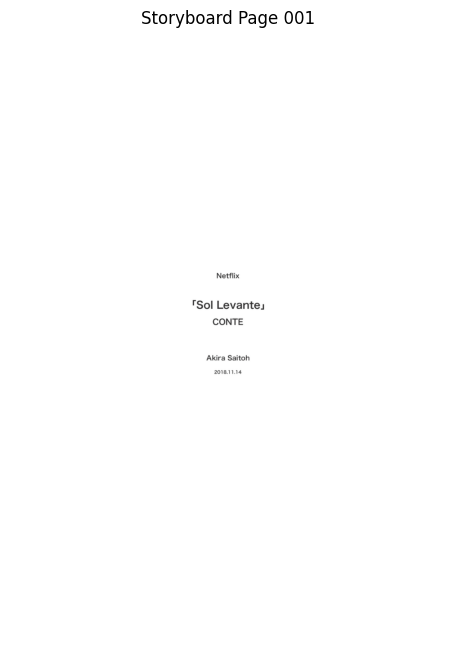

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(storyboard_pages[0])

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Storyboard Page 001")
plt.show()

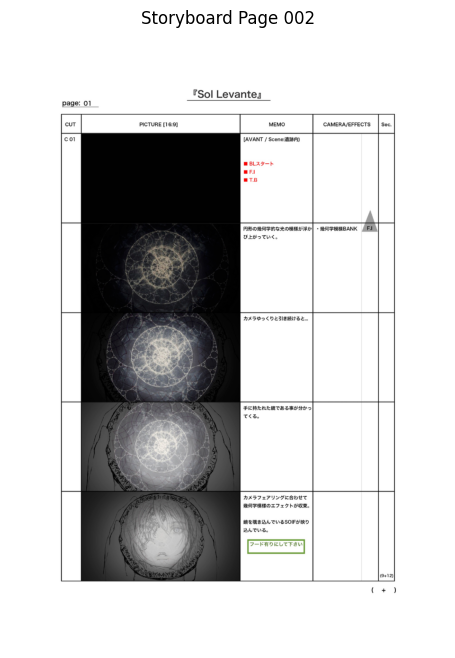

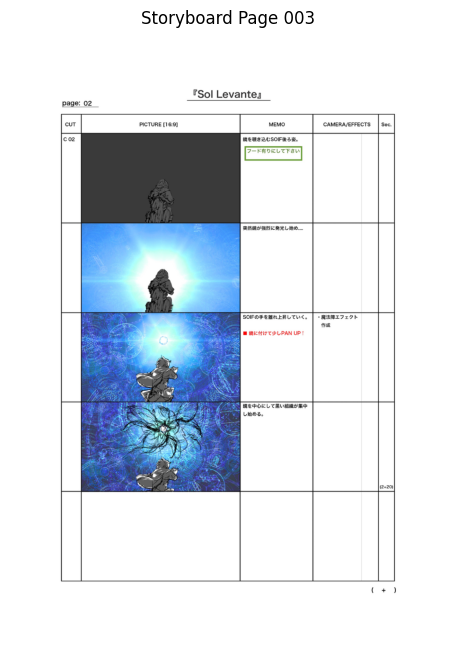

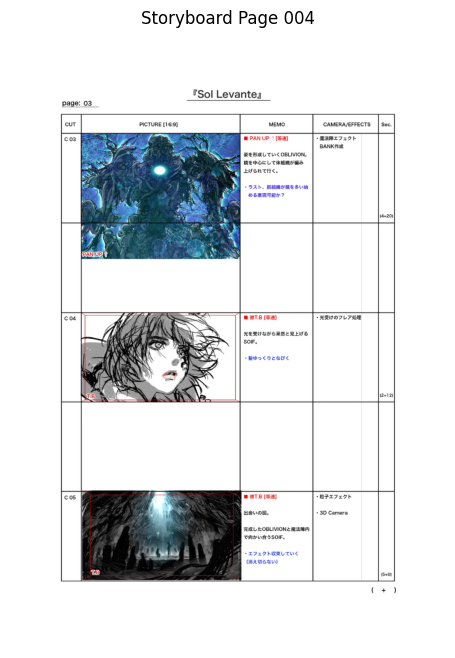

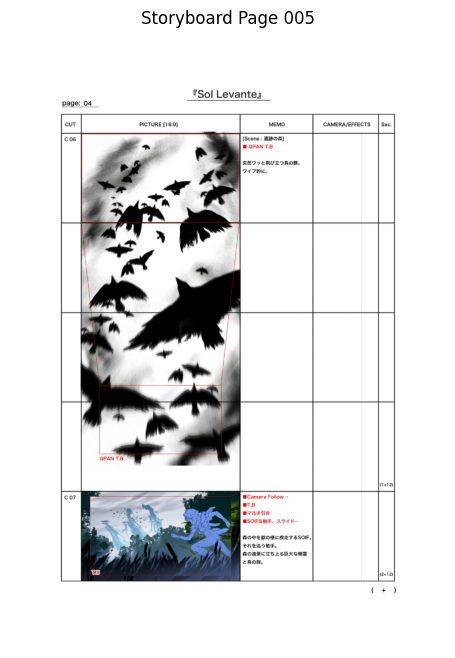

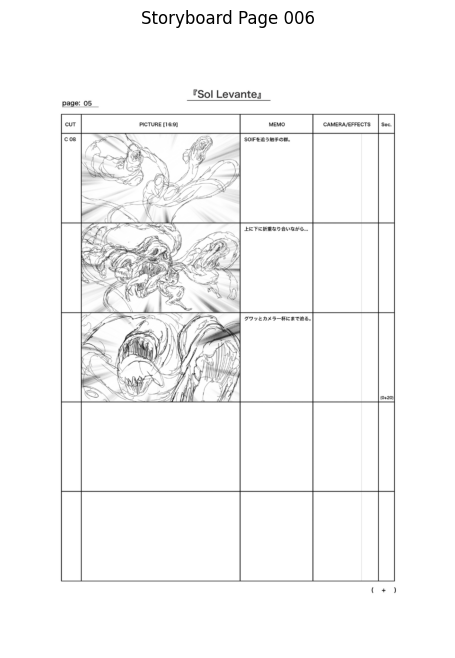

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

# 显示第 2 - 6 页
for i in range(1, 6):
    img = Image.open(storyboard_pages[i])

    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Storyboard Page {i+1:03d}")
    plt.show()

Image size: (1191, 1684)


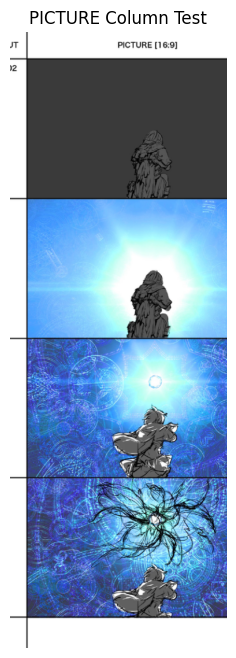

In [28]:
#提取 PICTURE 区域
from PIL import Image
import matplotlib.pyplot as plt

test_page = storyboard_pages[2]   # storyboard_page_003.png
img = Image.open(test_page)

print("Image size:", img.size)

# 先测试裁剪 PICTURE 区域
picture_column = img.crop((165, 230, 545, 1310))

plt.figure(figsize=(3, 8))
plt.imshow(picture_column)
plt.axis("off")
plt.title("PICTURE Column Test")
plt.show()

检测到的水平线 y 坐标：
[46, 536, 780, 1025]


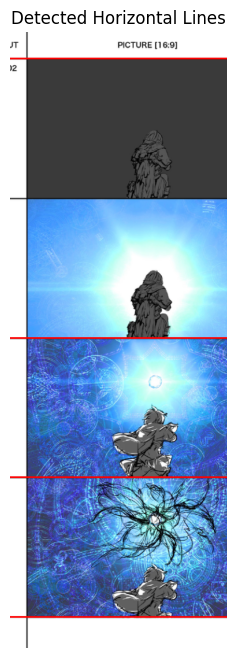

In [30]:
# 自动检测水平分割线并切出每个 storyboard 画面块。
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 读取测试页
test_page = storyboard_pages[2]
img = cv2.imread(str(test_page))

# 裁剪 PICTURE 区域
picture = img[230:1310, 165:545]

# 转灰度
gray = cv2.cvtColor(picture, cv2.COLOR_BGR2GRAY)

# 二值化：黑线会变成白色
_, binary = cv2.threshold(
    gray,
    100,
    255,
    cv2.THRESH_BINARY_INV
)

# 创建水平线检测 kernel
horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (150, 1)
)

# 提取水平线
horizontal_lines = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    horizontal_kernel
)

# 找轮廓
contours, _ = cv2.findContours(
    horizontal_lines,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# 提取所有水平线的 y 坐标
line_y = []

for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    if w > 200:
        line_y.append(y)

line_y = sorted(line_y)

print("检测到的水平线 y 坐标：")
print(line_y)

# 显示检测结果
preview = picture.copy()

for y in line_y:
    cv2.line(
        preview,
        (0, y),
        (preview.shape[1], y),
        (0, 0, 255),
        2
    )

preview_rgb = cv2.cvtColor(preview, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 8))
plt.imshow(preview_rgb)
plt.axis("off")
plt.title("Detected Horizontal Lines")
plt.show()

In [32]:
# 切出这一页的 storyboard panels
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# 输出文件夹
TEST_PANEL_DIR = SOL_ROOT / "outputs" / "storyboard_panels_test"
TEST_PANEL_DIR.mkdir(parents=True, exist_ok=True)

# 重新读取当前测试页
test_page = storyboard_pages[1]   # 如果你刚刚测的是第 2 页，就用 [1]
img = cv2.imread(str(test_page))

# 裁剪 PICTURE 区域
picture = img[230:1310, 165:545]

# 使用刚刚检测到的水平线
line_y = [46, 536, 780, 1025]

# 加入顶部和底部边界
boundaries = [0] + line_y + [picture.shape[0]]
boundaries = sorted(list(set(boundaries)))

print("全部边界:", boundaries)

saved_panels = []

for i in range(len(boundaries) - 1):
    y1 = boundaries[i]
    y2 = boundaries[i + 1]

    # 过滤太小的区域
    if (y2 - y1) < 120:
        continue

    # 去掉一点边框线，避免把黑线裁进去
    top = max(y1 + 3, 0)
    bottom = min(y2 - 3, picture.shape[0])

    panel = picture[top:bottom, :]

    save_path = TEST_PANEL_DIR / f"test_panel_{len(saved_panels)+1:02d}.png"
    cv2.imwrite(str(save_path), panel)
    saved_panels.append(save_path)

print("切出的 panel 数量:", len(saved_panels))
for p in saved_panels:
    print("-", p.name)

全部边界: [0, 46, 536, 780, 1025, 1080]
切出的 panel 数量: 3
- test_panel_01.png
- test_panel_02.png
- test_panel_03.png


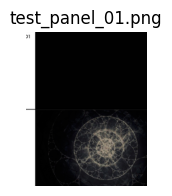

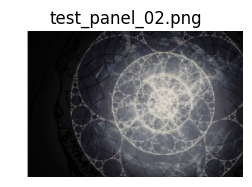

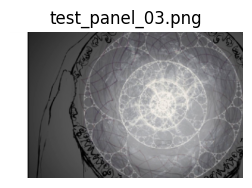

In [34]:
#预览切出来的 panel
import matplotlib.pyplot as plt
from PIL import Image

for p in saved_panels:
    img = Image.open(p)
    plt.figure(figsize=(3, 2))
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.name)
    plt.show()

In [36]:
#批量处理全部 storyboard 页面
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

# 输出目录
ALL_PANEL_ROOT = SOL_ROOT / "outputs" / "storyboard_panels_all"
ALL_PANEL_ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. 从整页中裁出 PICTURE 列
# -----------------------------
def crop_picture_column(page_path):
    img = cv2.imread(str(page_path))
    if img is None:
        return None

    # 这里用你前面测试成功的固定范围
    # 如果后面发现偏差，再调整
    picture = img[230:1310, 165:545]
    return picture

# -----------------------------
# 2. 检测水平分割线
# -----------------------------
def detect_horizontal_lines(picture):
    gray = cv2.cvtColor(picture, cv2.COLOR_BGR2GRAY)

    # 黑色横线通常比较暗，这里找“每一行有多少比例是深色像素”
    dark_mask = gray < 80
    row_ratio = dark_mask.mean(axis=1)

    # 候选线：深色比例较高的行
    candidate_rows = np.where(row_ratio > 0.45)[0]

    # 合并相邻行
    merged = []
    if len(candidate_rows) > 0:
        start = candidate_rows[0]
        group = [start]

        for y in candidate_rows[1:]:
            if y - group[-1] <= 8:
                group.append(y)
            else:
                merged.append(int(np.mean(group)))
                group = [y]
        merged.append(int(np.mean(group)))

    # 保留间隔较大的主要线
    final_lines = []
    for y in merged:
        if len(final_lines) == 0 or abs(y - final_lines[-1]) > 40:
            final_lines.append(y)

    return final_lines

# -----------------------------
# 3. 根据分割线裁出 panels
# -----------------------------
def split_panels(picture, line_y_list, min_height=120):
    h = picture.shape[0]

    boundaries = [0] + line_y_list + [h]
    boundaries = sorted(list(set(boundaries)))

    panels = []

    for i in range(len(boundaries) - 1):
        y1 = boundaries[i]
        y2 = boundaries[i + 1]

        if (y2 - y1) < min_height:
            continue

        top = max(y1 + 3, 0)
        bottom = min(y2 - 3, h)

        panel = picture[top:bottom, :]
        panels.append(panel)

    return panels, boundaries

# -----------------------------
# 4. 批量处理全部 storyboard 页面
# -----------------------------
panel_records = []

for page_idx, page_path in enumerate(storyboard_pages, start=1):
    picture = crop_picture_column(page_path)

    if picture is None:
        print(f"读取失败: {page_path.name}")
        continue

    line_y = detect_horizontal_lines(picture)
    panels, boundaries = split_panels(picture, line_y)

    # 每页单独一个文件夹
    page_dir = ALL_PANEL_ROOT / f"page_{page_idx:03d}"
    page_dir.mkdir(parents=True, exist_ok=True)

    for panel_idx, panel in enumerate(panels, start=1):
        save_path = page_dir / f"panel_{panel_idx:02d}.png"
        cv2.imwrite(str(save_path), panel)

        panel_records.append({
            "page_index": page_idx,
            "page_name": page_path.name,
            "panel_index": panel_idx,
            "panel_path": str(save_path),
            "line_y": str(line_y),
            "boundaries": str(boundaries)
        })

print("全部 storyboard 页面处理完成。")
print("总 panel 数量:", len(panel_records))

panel_df = pd.DataFrame(panel_records)
panel_df.head()

全部 storyboard 页面处理完成。
总 panel 数量: 180


,page_index,page_name,panel_index,panel_path,line_y,boundaries
0,1,storyboard_page_001.png,1,/Users/jank/Desktop/SolLevante/outputs/storybo...,[],"[0, 1080]"
1,2,storyboard_page_002.png,1,/Users/jank/Desktop/SolLevante/outputs/storybo...,"[344, 760, 1045]","[0, 344, 760, 1045, 1080]"
2,2,storyboard_page_002.png,2,/Users/jank/Desktop/SolLevante/outputs/storybo...,"[344, 760, 1045]","[0, 344, 760, 1045, 1080]"
3,2,storyboard_page_002.png,3,/Users/jank/Desktop/SolLevante/outputs/storybo...,"[344, 760, 1045]","[0, 344, 760, 1045, 1080]"
4,3,storyboard_page_003.png,1,/Users/jank/Desktop/SolLevante/outputs/storybo...,"[169, 536, 780, 998]","[0, 169, 536, 780, 998, 1080]"


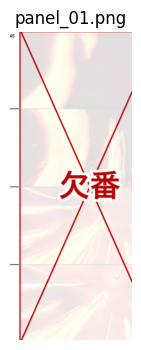

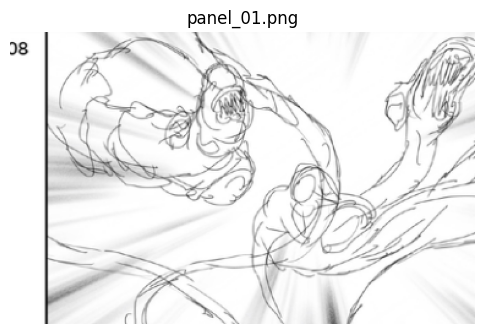

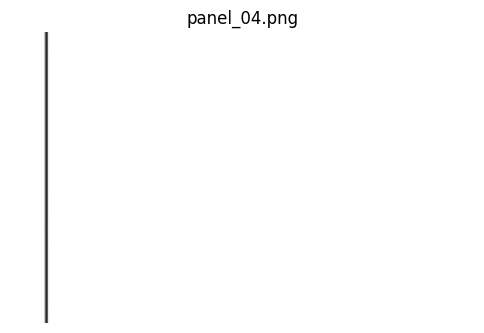

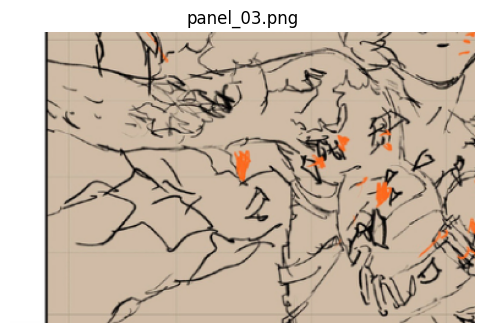

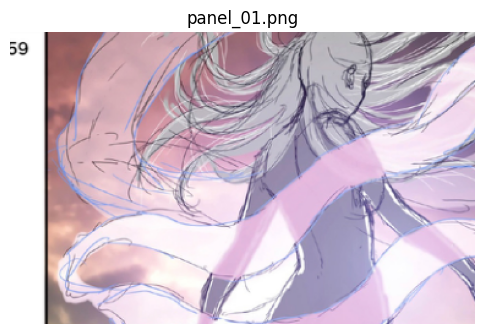

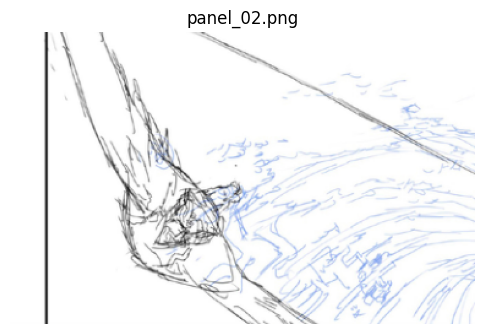

In [38]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(panel_df["panel_path"].tolist(), 6)

for p in sample_paths:
    img = Image.open(p)
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(p).name)
    plt.show()

现在已经有了storyboard 的 panel 数据集，也就是后面做 cross-modal coherence 的第一个模态输入。

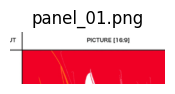

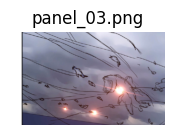

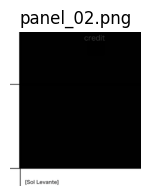

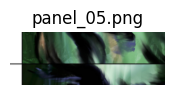

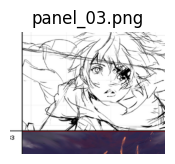

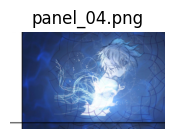

In [41]:
#随机查看
from PIL import Image
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(
    panel_df["panel_path"].tolist(),
    min(6, len(panel_df))
)

for p in sample_paths:

    img = Image.open(p)

    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(p).name)
    plt.show()

In [47]:
#用真正的表格线批量切全部 Storyboard
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import shutil

# 新建干净输出目录
CLEAN_PANEL_ROOT = SOL_ROOT / "outputs" / "storyboard_panels_clean"

# 如果之前运行过，先清空
if CLEAN_PANEL_ROOT.exists():
    shutil.rmtree(CLEAN_PANEL_ROOT)

CLEAN_PANEL_ROOT.mkdir(parents=True, exist_ok=True)


# ========================================
# 1. 检测整页真正的长水平表格线
# ========================================
def detect_table_lines(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, binary = cv2.threshold(
        gray,
        180,
        255,
        cv2.THRESH_BINARY_INV
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (500, 1)
    )

    horizontal = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    contours, _ = cv2.findContours(
        horizontal,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    lines = []

    for cnt in contours:

        x, y, w, h = cv2.boundingRect(cnt)

        # 只接受真正的长表格线
        if w > 600:
            lines.append(y)

    lines = sorted(lines)

    # 合并非常接近的重复线
    merged = []

    for y in lines:

        if not merged or y - merged[-1] > 10:
            merged.append(y)

    return merged


# ========================================
# 2. 批量处理全部页面
# ========================================

records = []

for page_idx, page_path in enumerate(storyboard_pages, start=1):

    img = cv2.imread(str(page_path))

    if img is None:
        print("读取失败:", page_path)
        continue

    lines = detect_table_lines(img)

    # 没检测到足够的线就跳过
    if len(lines) < 3:
        print(
            f"Page {page_idx:03d}: "
            f"横线数量异常 -> {len(lines)}"
        )
        continue

    # --------------------------
    # PICTURE 列 x 范围
    # 根据我们已经验证的 storyboard 模板
    # --------------------------
    x1 = 165
    x2 = 545

    page_dir = CLEAN_PANEL_ROOT / f"page_{page_idx:03d}"
    page_dir.mkdir(parents=True, exist_ok=True)

    panel_index = 1

    # 第一条通常是表格顶部
    # 第二条通常是 header 底部
    #
    # 因此从 lines[1] 开始向下切
    for i in range(1, len(lines) - 1):

        y1 = lines[i]
        y2 = lines[i + 1]

        height = y2 - y1

        # 太矮的区域不要
        if height < 100:
            continue

        # 去掉表格边框
        top = y1 + 3
        bottom = y2 - 3

        panel = img[
            top:bottom,
            x1:x2
        ]

        # 防止空图
        if panel.size == 0:
            continue

        save_path = (
            page_dir /
            f"panel_{panel_index:02d}.png"
        )

        cv2.imwrite(
            str(save_path),
            panel
        )

        records.append({
            "page_index": page_idx,
            "panel_index": panel_index,
            "panel_path": str(save_path),
            "y_start": y1,
            "y_end": y2,
            "height": height
        })

        panel_index += 1

    print(
        f"Page {page_idx:03d}: "
        f"lines={len(lines)}, "
        f"panels={panel_index-1}"
    )


# ========================================
# 3. 建立新的 panel dataframe
# ========================================

clean_panel_df = pd.DataFrame(records)

print("Storyboard Clean Extraction")
print("总页面:", len(storyboard_pages))
print("成功 panel 数量:", len(clean_panel_df))

display(clean_panel_df.head(10))

Page 001: 横线数量异常 -> 0
Page 002: lines=7, panels=5
Page 003: lines=7, panels=5
Page 004: lines=7, panels=5
Page 005: lines=7, panels=5
Page 006: lines=7, panels=5
Page 007: lines=7, panels=5
Page 008: lines=7, panels=5
Page 009: lines=7, panels=5
Page 010: lines=7, panels=5
Page 011: lines=7, panels=5
Page 012: lines=7, panels=5
Page 013: lines=7, panels=5
Page 014: lines=7, panels=5
Page 015: lines=7, panels=5
Page 016: lines=7, panels=5
Page 017: lines=7, panels=5
Page 018: lines=7, panels=5
Page 019: lines=7, panels=5
Page 020: lines=7, panels=5
Page 021: lines=7, panels=5
Page 022: lines=7, panels=5
Page 023: lines=7, panels=5
Page 024: lines=7, panels=5
Page 025: lines=7, panels=5
Page 026: lines=7, panels=5
Page 027: lines=7, panels=5
Page 028: lines=7, panels=5
Page 029: lines=7, panels=5
Page 030: lines=6, panels=4
Page 031: lines=7, panels=5
Page 032: lines=7, panels=5
Page 033: lines=7, panels=5
Page 034: lines=7, panels=5
Page 035: lines=7, panels=5
Page 036: lines=7, panels=

,page_index,panel_index,panel_path,y_start,y_end,height
0,2,1,/Users/jank/Desktop/SolLevante/outputs/storybo...,276,521,245
1,2,2,/Users/jank/Desktop/SolLevante/outputs/storybo...,521,766,245
2,2,3,/Users/jank/Desktop/SolLevante/outputs/storybo...,766,1010,244
3,2,4,/Users/jank/Desktop/SolLevante/outputs/storybo...,1010,1255,245
4,2,5,/Users/jank/Desktop/SolLevante/outputs/storybo...,1255,1500,245
5,3,1,/Users/jank/Desktop/SolLevante/outputs/storybo...,276,521,245
6,3,2,/Users/jank/Desktop/SolLevante/outputs/storybo...,521,766,245
7,3,3,/Users/jank/Desktop/SolLevante/outputs/storybo...,766,1010,244
8,3,4,/Users/jank/Desktop/SolLevante/outputs/storybo...,1010,1255,245
9,3,5,/Users/jank/Desktop/SolLevante/outputs/storybo...,1255,1500,245


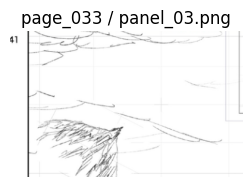

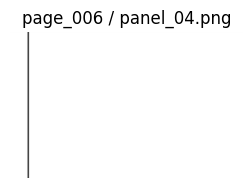

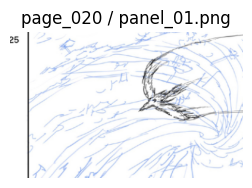

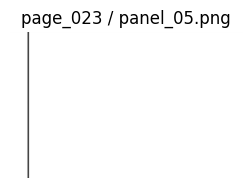

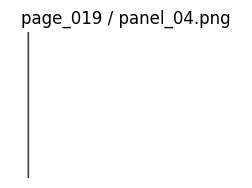

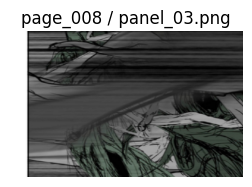

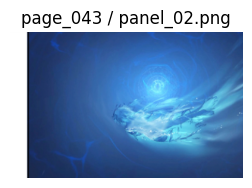

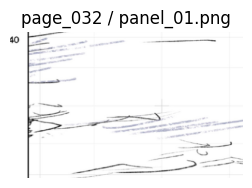

In [51]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(
    clean_panel_df["panel_path"].tolist(),
    min(8, len(clean_panel_df))
)

for path in sample_paths:

    image = Image.open(path)

    plt.figure(figsize=(3, 2))
    plt.imshow(image)
    plt.axis("off")

    # 同时显示 page + panel
    p = Path(path)

    plt.title(
        f"{p.parent.name} / {p.name}"
    )

    plt.show()

In [53]:
#Storyboard 的索引保存
STORYBOARD_CSV = SOL_ROOT / "outputs" / "storyboard_panels.csv"

clean_panel_df.to_csv(
    STORYBOARD_CSV,
    index=False
)

print("Storyboard index 保存完成:")
print(STORYBOARD_CSV)

print("Panel 数量:", len(clean_panel_df))

Storyboard index 保存完成:
/Users/jank/Desktop/SolLevante/outputs/storyboard_panels.csv
Panel 数量: 231


## 2.2 Animatic 预处理

In [56]:
import sys

!{sys.executable} -m pip install scenedetect

In [58]:
from scenedetect import open_video, SceneManager
from scenedetect.detectors import ContentDetector

print("PySceneDetect 导入成功")

PySceneDetect 导入成功


In [60]:
# 自动检测 Animatic 镜头
from scenedetect import open_video, SceneManager
from scenedetect.detectors import ContentDetector

video = open_video(str(ANIMATIC_PATH))

scene_manager = SceneManager()

# threshold 越低越敏感
scene_manager.add_detector(
    ContentDetector(threshold=27.0)
)

scene_manager.detect_scenes(video)

scene_list = scene_manager.get_scene_list()

print("检测到的 Animatic shots:", len(scene_list))

检测到的 Animatic shots: 70


In [62]:
for i, (start, end) in enumerate(scene_list[:10], start=1):

    print(
        f"Shot {i:03d}:",
        f"{start.get_seconds():.2f}s",
        "→",
        f"{end.get_seconds():.2f}s",
        "|",
        f"{(end - start).get_seconds():.2f}s"
    )

Shot 001: 0.00s → 2.00s | 2.00s
Shot 002: 2.00s → 8.09s | 6.09s
Shot 003: 8.09s → 10.22s | 2.13s
Shot 004: 10.22s → 18.98s | 8.76s
Shot 005: 18.98s → 21.35s | 2.38s
Shot 006: 21.35s → 25.82s | 4.46s
Shot 007: 25.82s → 27.86s | 2.04s
Shot 008: 27.86s → 33.07s | 5.21s
Shot 009: 33.07s → 34.08s | 1.00s
Shot 010: 34.08s → 36.20s | 2.13s


/var/folders/rt/4z0v6ccj2zl2v14n97gd3h2m0000gn/T/ipykernel_82892/3439333072.py:5: DeprecationWarning: get_seconds() is deprecated, use the `seconds` property instead.
  f"{start.get_seconds():.2f}s",
/var/folders/rt/4z0v6ccj2zl2v14n97gd3h2m0000gn/T/ipykernel_82892/3439333072.py:7: DeprecationWarning: get_seconds() is deprecated, use the `seconds` property instead.
  f"{end.get_seconds():.2f}s",
/var/folders/rt/4z0v6ccj2zl2v14n97gd3h2m0000gn/T/ipykernel_82892/3439333072.py:9: DeprecationWarning: get_seconds() is deprecated, use the `seconds` property instead.
  f"{(end - start).get_seconds():.2f}s"


In [64]:
#建立输出目录
ANIMATIC_KEYFRAME_DIR = SOL_ROOT / "outputs" / "animatic_keyframes"
ANIMATIC_KEYFRAME_DIR.mkdir(parents=True, exist_ok=True)

print("Animatic keyframe output:")
print(ANIMATIC_KEYFRAME_DIR)

Animatic keyframe output:
/Users/jank/Desktop/SolLevante/outputs/animatic_keyframes


In [66]:
# 为 70 个 Animatic Shot 提取中间关键帧
import cv2
import pandas as pd

cap = cv2.VideoCapture(str(ANIMATIC_PATH))

fps = cap.get(cv2.CAP_PROP_FPS)

print("Animatic FPS:", fps)

animatic_records = []

for shot_id, (start, end) in enumerate(scene_list, start=1):

    start_sec = start.seconds
    end_sec = end.seconds
    duration = end_sec - start_sec

    # 取 shot 中间时间
    middle_sec = (start_sec + end_sec) / 2

    # 对应帧位置
    middle_frame = int(middle_sec * fps)

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        middle_frame
    )

    ret, frame = cap.read()

    if not ret or frame is None:
        print(f"Shot {shot_id:03d} 提取失败")
        continue

    save_path = (
        ANIMATIC_KEYFRAME_DIR /
        f"animatic_shot_{shot_id:03d}.png"
    )

    cv2.imwrite(
        str(save_path),
        frame
    )

    animatic_records.append({
        "shot_id": shot_id,
        "start_sec": start_sec,
        "end_sec": end_sec,
        "duration_sec": duration,
        "middle_sec": middle_sec,
        "middle_frame": middle_frame,
        "keyframe_path": str(save_path)
    })

cap.release()

animatic_df = pd.DataFrame(animatic_records)

print("Animatic keyframes 提取完成")
print("成功数量:", len(animatic_df))

display(animatic_df.head(10))

Animatic FPS: 23.976023976023978
Animatic keyframes 提取完成
成功数量: 70


,shot_id,start_sec,end_sec,duration_sec,middle_sec,middle_frame,keyframe_path
0,1,0.000000,2.002000,2.002000,1.001000,24,/Users/jank/Desktop/SolLevante/outputs/animati...
1,2,2.002000,8.091417,6.089417,5.046708,121,/Users/jank/Desktop/SolLevante/outputs/animati...
2,3,8.091417,10.218542,2.127125,9.154979,219,/Users/jank/Desktop/SolLevante/outputs/animati...
3,4,10.218542,18.977292,8.758750,14.597917,350,/Users/jank/Desktop/SolLevante/outputs/animati...
4,5,18.977292,21.354667,2.377375,20.165979,483,/Users/jank/Desktop/SolLevante/outputs/animati...
5,6,21.354667,25.817458,4.462791,23.586062,565,/Users/jank/Desktop/SolLevante/outputs/animati...
6,7,25.817458,27.861167,2.043709,26.839312,643,/Users/jank/Desktop/SolLevante/outputs/animati...
7,8,27.861167,33.074708,5.213541,30.467937,730,/Users/jank/Desktop/SolLevante/outputs/animati...
8,9,33.074708,34.075708,1.001000,33.575208,804,/Users/jank/Desktop/SolLevante/outputs/animati...
9,10,34.075708,36.202833,2.127125,35.139270,842,/Users/jank/Desktop/SolLevante/outputs/animati...


In [67]:
ANIMATIC_CSV = (
    SOL_ROOT /
    "outputs" /
    "animatic_shots.csv"
)

animatic_df.to_csv(
    ANIMATIC_CSV,
    index=False
)

print("保存完成:")
print(ANIMATIC_CSV)

保存完成:
/Users/jank/Desktop/SolLevante/outputs/animatic_shots.csv


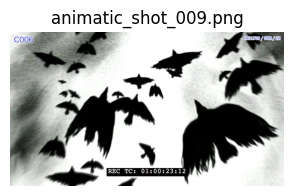

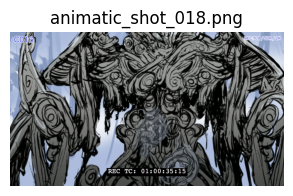

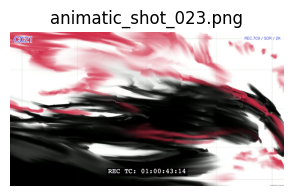

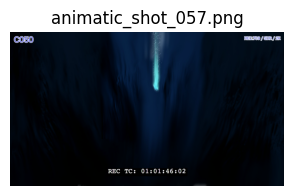

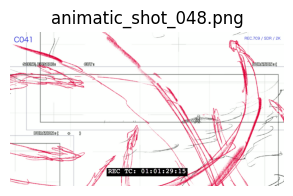

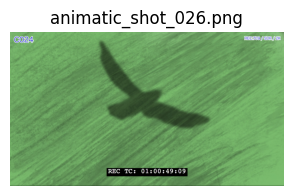

In [68]:
from PIL import Image
import matplotlib.pyplot as plt
import random

sample_paths = random.sample(
    animatic_df["keyframe_path"].tolist(),
    min(6, len(animatic_df))
)

for path in sample_paths:

    image = Image.open(path)

    plt.figure(figsize=(4, 2))
    plt.imshow(image)
    plt.axis("off")
    plt.title(Path(path).name)
    plt.show()

## 2.3 Final Video 预处理

In [73]:
# 检测 Final Video 镜头
from scenedetect import open_video, SceneManager
from scenedetect.detectors import ContentDetector

final_video = open_video(str(FINAL_PATH))

final_scene_manager = SceneManager()

final_scene_manager.add_detector(
    ContentDetector(threshold=27.0)
)

final_scene_manager.detect_scenes(final_video)

final_scene_list = final_scene_manager.get_scene_list()

print("检测到的 Final shots:", len(final_scene_list))

检测到的 Final shots: 62


In [75]:
# 然后看前 10 个
for i, (start, end) in enumerate(final_scene_list[:10], start=1):

    print(
        f"Shot {i:03d}:",
        f"{start.seconds:.2f}s",
        "→",
        f"{end.seconds:.2f}s",
        "|",
        f"{(end - start).seconds:.2f}s"
    )

Shot 001: 0.00s → 8.17s | 8.17s
Shot 002: 8.17s → 18.92s | 10.75s
Shot 003: 18.92s → 21.62s | 2.71s
Shot 004: 21.62s → 27.08s | 5.46s
Shot 005: 27.08s → 29.96s | 2.88s
Shot 006: 29.96s → 35.29s | 5.33s
Shot 007: 35.29s → 36.17s | 0.88s
Shot 008: 36.17s → 38.46s | 2.29s
Shot 009: 38.46s → 41.00s | 2.54s
Shot 010: 41.00s → 41.79s | 0.79s


In [77]:
# Final Shot 提取中间关键帧
FINAL_KEYFRAME_DIR = SOL_ROOT / "outputs" / "final_keyframes"
FINAL_KEYFRAME_DIR.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(FINAL_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)

final_records = []

for shot_id, (start, end) in enumerate(final_scene_list, start=1):
    start_sec = start.seconds
    end_sec = end.seconds
    middle_sec = (start_sec + end_sec) / 2
    middle_frame = int(middle_sec * fps)

    cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
    ret, frame = cap.read()

    if not ret or frame is None:
        print(f"Shot {shot_id:03d} 提取失败")
        continue

    save_path = FINAL_KEYFRAME_DIR / f"final_shot_{shot_id:03d}.png"
    cv2.imwrite(str(save_path), frame)

    final_records.append({
        "shot_id": shot_id,
        "start_sec": start_sec,
        "end_sec": end_sec,
        "middle_sec": middle_sec,
        "keyframe_path": str(save_path)
    })

cap.release()

final_df = pd.DataFrame(final_records)

print("Final keyframes 成功数量:", len(final_df))

Final keyframes 成功数量: 62


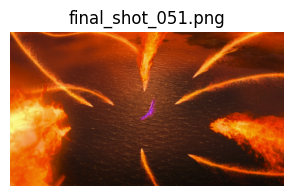

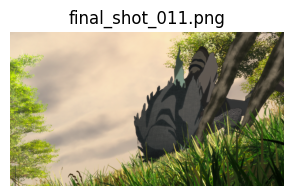

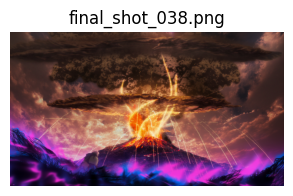

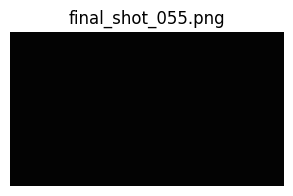

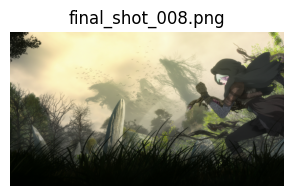

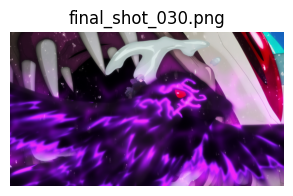

In [78]:
# 随机检查 Final 关键帧
from PIL import Image
import matplotlib.pyplot as plt
import random
from pathlib import Path

sample_paths = random.sample(
    final_df["keyframe_path"].tolist(),
    min(6, len(final_df))
)

for path in sample_paths:
    img = Image.open(path)

    plt.figure(figsize=(5, 2))
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(path).name)
    plt.show()

# 3. CLIP 视觉特征提取（Visual Feature Extraction）

由于 Storyboard、Animatic 和 Final Video 在视觉风格上存在明显差异，本项目使用预训练 CLIP 模型将三种 Evidence 转换为统一的视觉 Embedding。随后使用这些 Embedding 计算不同制作阶段之间的语义相似度。

In [81]:
# 安装并加载 CLIP
import sys
!{sys.executable} -m pip install transformers torch torchvision

In [83]:
import torch
from transformers import CLIPModel, CLIPProcessor

device = "mps" if torch.backends.mps.is_available() else "cpu"

model_name = "openai/clip-vit-base-patch32"

clip_model = CLIPModel.from_pretrained(model_name)
clip_processor = CLIPProcessor.from_pretrained(model_name)

clip_model = clip_model.to(device)
clip_model.eval()

print("CLIP 加载成功")
print("Device:", device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP 加载成功
Device: mps


In [85]:
# 先测试 1 张图片能不能成功生成 CLIP embedding
from PIL import Image
import torch
import torch.nn.functional as F

def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        vision_outputs = clip_model.vision_model(
            pixel_values=pixel_values
        )

        pooled_output = vision_outputs.pooler_output

        features = clip_model.visual_projection(
            pooled_output
        )

    features = F.normalize(
        features,
        p=2,
        dim=-1
    )

    return features

In [ ]:
test_path = final_df.iloc[0]["keyframe_path"]

test_embedding = get_image_embedding(test_path)

print("测试图片:")
print(test_path)

print("Embedding shape:")
print(test_embedding.shape)

## 3.2 把全部 Final 的 62 张 keyframe 转成 CLIP embedding

In [87]:
# 把全部 Final 的 62 张 keyframe 转成 CLIP embedding。
final_embeddings = []

for i, row in final_df.iterrows():
    emb = get_image_embedding(row["keyframe_path"])

    final_embeddings.append({
        "shot_id": row["shot_id"],
        "keyframe_path": row["keyframe_path"],
        "embedding": emb.cpu()
    })

print("Final embeddings 提取完成")
print("数量:", len(final_embeddings))
print("单个 embedding shape:", final_embeddings[0]["embedding"].shape)

Final embeddings 提取完成
数量: 62
单个 embedding shape: torch.Size([1, 512])


## 3.3 把 70 个 Animatic keyframes 也转成 CLIP embedding

In [90]:
# 把 70 个 Animatic keyframes 也转成 CLIP embedding。
animatic_embeddings = []

for i, row in animatic_df.iterrows():
    emb = get_image_embedding(row["keyframe_path"])

    animatic_embeddings.append({
        "shot_id": row["shot_id"],
        "keyframe_path": row["keyframe_path"],
        "embedding": emb.cpu()
    })

print("Animatic embeddings 提取完成")
print("数量:", len(animatic_embeddings))
print("单个 embedding shape:", animatic_embeddings[0]["embedding"].shape)

Animatic embeddings 提取完成
数量: 70
单个 embedding shape: torch.Size([1, 512])


## 3.4  Storyboard 的 231 个 panels → CLIP embeddings

In [93]:
# Storyboard 的 231 个 panels → CLIP embeddings。
storyboard_embeddings = []

for i, row in clean_panel_df.iterrows():
    emb = get_image_embedding(row["panel_path"])

    storyboard_embeddings.append({
        "page_index": row["page_index"],
        "panel_index": row["panel_index"],
        "panel_path": row["panel_path"],
        "embedding": emb.cpu()
    })

print("Storyboard embeddings 提取完成")
print("数量:", len(storyboard_embeddings))
print("单个 embedding shape:", storyboard_embeddings[0]["embedding"].shape)

Storyboard embeddings 提取完成
数量: 231
单个 embedding shape: torch.Size([1, 512])


# 4. 跨阶段 Evidence Matching 

本阶段使用前面提取的 CLIP Embeddings 计算不同制作阶段之间的视觉相似度，主要分析 Animatic → Final 和 Storyboard → Animatic 两组 Evidence Relationship。随后加入时间顺序约束，建立符合实际制作流程的跨阶段 Evidence Mapping。

## 4.1 计算 Animatic ↔ Final 的相似度矩阵

In [98]:
# 计算 Animatic ↔ Final 的相似度矩阵。
import torch
import numpy as np

# 拼成矩阵
animatic_matrix = torch.cat(
    [x["embedding"] for x in animatic_embeddings],
    dim=0
)

final_matrix = torch.cat(
    [x["embedding"] for x in final_embeddings],
    dim=0
)

print("Animatic matrix:", animatic_matrix.shape)
print("Final matrix:", final_matrix.shape)

# 因为 embedding 已经 normalize 过，
# 点积就是 cosine similarity
similarity_matrix = animatic_matrix @ final_matrix.T

print("Similarity matrix:", similarity_matrix.shape)

Animatic matrix: torch.Size([70, 512])
Final matrix: torch.Size([62, 512])
Similarity matrix: torch.Size([70, 62])


In [100]:
top_matches = []

for i in range(similarity_matrix.shape[0]):
    scores = similarity_matrix[i]

    # 找最高相似度
    best_score, best_idx = torch.max(scores, dim=0)

    top_matches.append({
        "animatic_shot": i + 1,
        "best_final_shot": int(best_idx.item()) + 1,
        "similarity": float(best_score.item())
    })

match_df = pd.DataFrame(top_matches)

display(match_df.head(10))

,animatic_shot,best_final_shot,similarity
0,1,55,0.666542
1,2,55,0.759749
2,3,55,0.753808
3,4,2,0.784492
4,5,3,0.791507
5,6,4,0.781201
6,7,61,0.807759
7,8,6,0.767903
8,9,46,0.697414
9,10,11,0.759506


得分不是很高，顺序很乱。因为 CLIP 现在只看“图片像不像”，完全不知道电影镜头应该按照时间顺序对应。

## 4.2 查看全部 Animatic → Final 的最佳匹配

In [104]:
# 查看全部 Animatic → Final 的最佳匹配
pd.set_option("display.max_rows", None)

display(match_df)

,animatic_shot,best_final_shot,similarity
0,1,55,0.666542
1,2,55,0.759749
2,3,55,0.753808
3,4,2,0.784492
4,5,3,0.791507
5,6,4,0.781201
6,7,61,0.807759
7,8,6,0.767903
8,9,46,0.697414
9,10,11,0.759506


In [106]:
# 检查相邻匹配是否保持时间顺序
final_ids = match_df["best_final_shot"].values

order_correct = 0

for i in range(1, len(final_ids)):
    if final_ids[i] >= final_ids[i - 1]:
        order_correct += 1

order_ratio = order_correct / (len(final_ids) - 1)

print("保持顺序的比例:", round(order_ratio, 4))

保持顺序的比例: 0.6232


## 4.3 给 Animatic → Final 匹配加上“顺序约束”。最简单先用动态规划，强制匹配结果不能往回跳

In [109]:
# 给 Animatic → Final 匹配加上“顺序约束”。最简单先用动态规划，强制匹配结果不能往回跳。
import numpy as np

sim = similarity_matrix.cpu().numpy()

n_animatic, n_final = sim.shape

# dp[i, j]:
# 前 i 个 animatic，且第 i 个匹配到 final j 时的最大累计相似度
dp = np.full((n_animatic, n_final), -np.inf)

# 记录路径
parent = np.full((n_animatic, n_final), -1, dtype=int)

# 第一行直接初始化
dp[0] = sim[0]

# 动态规划
for i in range(1, n_animatic):
    for j in range(n_final):

        # 只能从 <= j 的 Final shot 转移过来
        previous_scores = dp[i - 1, :j + 1]

        best_prev_j = np.argmax(previous_scores)

        dp[i, j] = previous_scores[best_prev_j] + sim[i, j]

        parent[i, j] = best_prev_j

# 回溯最优路径
best_path = np.zeros(n_animatic, dtype=int)

best_path[-1] = np.argmax(dp[-1])

for i in range(n_animatic - 1, 0, -1):
    best_path[i - 1] = parent[i, best_path[i]]

# 转成 1-based shot 编号
ordered_final_shots = best_path + 1

print("前20个顺序约束匹配:")
print(ordered_final_shots[:20])

print("\n是否完全非递减:")
print(np.all(np.diff(ordered_final_shots) >= 0))

前20个顺序约束匹配:
[ 2  2  2  2  3  4  5  6  7 11 19 19 19 19 19 19 19 19 22 23]

是否完全非递减:
True


In [111]:
# 把这个“顺序约束后的匹配结果”整理成一个 DataFrame，方便后面查看每个 Animatic shot 对应哪个 Final shot，以及对应的 CLIP similarity。
ordered_matches = []

for i in range(n_animatic):
    final_idx = best_path[i]

    ordered_matches.append({
        "animatic_shot": i + 1,
        "matched_final_shot": final_idx + 1,
        "similarity": sim[i, final_idx]
    })

ordered_match_df = pd.DataFrame(ordered_matches)

display(ordered_match_df.head(20))

,animatic_shot,matched_final_shot,similarity
0,1,2,0.569482
1,2,2,0.629134
2,3,2,0.631137
3,4,2,0.784492
4,5,3,0.791507
5,6,4,0.781201
6,7,5,0.728517
7,8,6,0.767903
8,9,7,0.672842
9,10,11,0.759506


In [113]:
# 比较“原始最近邻匹配”和“顺序约束匹配”的平均 CLIP similarity。这样我们能量化“为了保证时间顺序，牺牲了多少视觉相似度”。
# 原始独立最近邻匹配的平均 similarity
raw_mean_similarity = match_df["similarity"].mean()

# 顺序约束后的平均 similarity
ordered_mean_similarity = ordered_match_df["similarity"].mean()

print("原始最近邻平均 similarity:",
      round(raw_mean_similarity, 4))

print("顺序约束平均 similarity:",
      round(ordered_mean_similarity, 4))

print("similarity 下降:",
      round(raw_mean_similarity - ordered_mean_similarity, 4))

原始最近邻平均 similarity: 0.7679
顺序约束平均 similarity: 0.7402
similarity 下降: 0.0277


Storyboard → Animatic

In [116]:
# 建立 Storyboard 231 × Animatic 70 的 CLIP similarity matrix。
# Storyboard embeddings 拼成矩阵
storyboard_matrix = torch.cat(
    [x["embedding"] for x in storyboard_embeddings],
    dim=0
)

# Animatic matrix 前面已经生成过
print("Storyboard matrix:", storyboard_matrix.shape)
print("Animatic matrix:", animatic_matrix.shape)

# 计算 cosine similarity
storyboard_animatic_similarity = (
    storyboard_matrix @ animatic_matrix.T
)

print(
    "Storyboard-Animatic similarity matrix:",
    storyboard_animatic_similarity.shape
)

Storyboard matrix: torch.Size([231, 512])
Animatic matrix: torch.Size([70, 512])
Storyboard-Animatic similarity matrix: torch.Size([231, 70])


In [118]:
# 先为每个 Storyboard panel 找最相似的 Animatic shot，和我们刚才做 Animatic → Final 一样，先看“无顺序约束”的基础结果。
storyboard_animatic_matches = []

for i in range(storyboard_animatic_similarity.shape[0]):
    scores = storyboard_animatic_similarity[i]

    best_score, best_idx = torch.max(scores, dim=0)

    storyboard_animatic_matches.append({
        "storyboard_panel": i + 1,
        "best_animatic_shot": int(best_idx.item()) + 1,
        "similarity": float(best_score.item())
    })

storyboard_animatic_match_df = pd.DataFrame(
    storyboard_animatic_matches
)

display(storyboard_animatic_match_df.head(20))

,storyboard_panel,best_animatic_shot,similarity
0,1,67,0.767074
1,2,4,0.854863
2,3,4,0.861604
3,4,4,0.846278
4,5,19,0.835824
5,6,16,0.839433
6,7,36,0.802281
7,8,32,0.827507
8,9,5,0.864142
9,10,67,0.790130


In [120]:
# 先给 Storyboard → Animatic 加上单调顺序约束
sim_sa = storyboard_animatic_similarity.cpu().numpy()

n_storyboard, n_animatic = sim_sa.shape

dp_sa = np.full((n_storyboard, n_animatic), -np.inf)
parent_sa = np.full((n_storyboard, n_animatic), -1, dtype=int)

# 第一张 storyboard panel
dp_sa[0] = sim_sa[0]

# 动态规划
for i in range(1, n_storyboard):
    for j in range(n_animatic):

        previous_scores = dp_sa[i - 1, :j + 1]

        best_prev_j = np.argmax(previous_scores)

        dp_sa[i, j] = (
            previous_scores[best_prev_j]
            + sim_sa[i, j]
        )

        parent_sa[i, j] = best_prev_j

# 回溯
best_path_sa = np.zeros(n_storyboard, dtype=int)

best_path_sa[-1] = np.argmax(dp_sa[-1])

for i in range(n_storyboard - 1, 0, -1):
    best_path_sa[i - 1] = parent_sa[
        i,
        best_path_sa[i]
    ]

ordered_animatic_shots = best_path_sa + 1

print("前20个 Storyboard → Animatic 顺序匹配:")
print(ordered_animatic_shots[:20])

print("\n是否完全非递减:")
print(np.all(np.diff(ordered_animatic_shots) >= 0))

前20个 Storyboard → Animatic 顺序匹配:
[ 2  4  4  4  4  5  5  5  5  6  6  6  7  7  8  9  9  9  9 10]

是否完全非递减:
True


In [122]:
# 把顺序约束后的结果整理成 DataFrame，并计算平均 similarity。
ordered_sa_matches = []

for i in range(n_storyboard):
    animatic_idx = best_path_sa[i]

    ordered_sa_matches.append({
        "storyboard_panel": i + 1,
        "matched_animatic_shot": animatic_idx + 1,
        "similarity": sim_sa[i, animatic_idx]
    })

ordered_sa_match_df = pd.DataFrame(ordered_sa_matches)

display(ordered_sa_match_df.head(20))

print(
    "\n顺序约束平均 similarity:",
    round(ordered_sa_match_df["similarity"].mean(), 4)
)

,storyboard_panel,matched_animatic_shot,similarity
0,1,2,0.755314
1,2,4,0.854863
2,3,4,0.861604
3,4,4,0.846278
4,5,4,0.773247
5,6,5,0.741518
6,7,5,0.758574
7,8,5,0.820866
8,9,5,0.864142
9,10,6,0.601821



顺序约束平均 similarity: 0.7903


In [124]:
# 和原始最近邻平均 similarity 比较一下，看看为了保证顺序牺牲了多少视觉相似度。
raw_sa_mean = storyboard_animatic_match_df["similarity"].mean()

ordered_sa_mean = ordered_sa_match_df["similarity"].mean()

print("原始最近邻平均 similarity:",
      round(raw_sa_mean, 4))

print("顺序约束平均 similarity:",
      round(ordered_sa_mean, 4))

print("similarity 下降:",
      round(raw_sa_mean - ordered_sa_mean, 4))

原始最近邻平均 similarity: 0.8285
顺序约束平均 similarity: 0.7903
similarity 下降: 0.0382


In [126]:
# 建立 Animatic → Final 的映射
animatic_to_final = dict(
    zip(
        ordered_match_df["animatic_shot"],
        ordered_match_df["matched_final_shot"]
    )
)

# 建立完整 Storyboard → Animatic → Final evidence chain
evidence_chain = []

for _, row in ordered_sa_match_df.iterrows():

    storyboard_panel = int(row["storyboard_panel"])
    animatic_shot = int(row["matched_animatic_shot"])

    final_shot = animatic_to_final.get(animatic_shot)

    evidence_chain.append({
        "storyboard_panel": storyboard_panel,
        "animatic_shot": animatic_shot,
        "final_shot": final_shot,
        "storyboard_animatic_similarity": float(row["similarity"])
    })

evidence_chain_df = pd.DataFrame(evidence_chain)

display(evidence_chain_df.head(20))

,storyboard_panel,animatic_shot,final_shot,storyboard_animatic_similarity
0,1,2,2,0.755314
1,2,4,2,0.854863
2,3,4,2,0.861604
3,4,4,2,0.846278
4,5,4,2,0.773247
5,6,5,3,0.741518
6,7,5,3,0.758574
7,8,5,3,0.820866
8,9,5,3,0.864142
9,10,6,4,0.601821


In [128]:
# Animatic → Final similarity 映射
animatic_final_similarity = dict(
    zip(
        ordered_match_df["animatic_shot"],
        ordered_match_df["similarity"]
    )
)

# 加入第二段 similarity
evidence_chain_df["animatic_final_similarity"] = (
    evidence_chain_df["animatic_shot"]
    .map(animatic_final_similarity)
)

display(evidence_chain_df.head(20))

,storyboard_panel,animatic_shot,final_shot,storyboard_animatic_similarity,animatic_final_similarity
0,1,2,2,0.755314,0.629134
1,2,4,2,0.854863,0.784492
2,3,4,2,0.861604,0.784492
3,4,4,2,0.846278,0.784492
4,5,4,2,0.773247,0.784492
5,6,5,3,0.741518,0.791507
6,7,5,3,0.758574,0.791507
7,8,5,3,0.820866,0.791507
8,9,5,3,0.864142,0.791507
9,10,6,4,0.601821,0.781201


# 5.建立 Evidence Chain 的基础评分体系

## 5.1 先计算一个最简单的 chain-level coherence measurement

In [132]:
# 先计算一个最简单的 chain-level coherence measurement
evidence_chain_df["chain_coherence_measurement"] = (
    evidence_chain_df[
        [
            "storyboard_animatic_similarity",
            "animatic_final_similarity"
        ]
    ].mean(axis=1)
)

display(
    evidence_chain_df[
        [
            "storyboard_panel",
            "animatic_shot",
            "final_shot",
            "storyboard_animatic_similarity",
            "animatic_final_similarity",
            "chain_coherence_measurement"
        ]
    ].head(20)
)

print(
    "\n平均 chain coherence measurement:",
    round(
        evidence_chain_df["chain_coherence_measurement"].mean(),
        4
    )
)

,storyboard_panel,animatic_shot,final_shot,storyboard_animatic_similarity,animatic_final_similarity,chain_coherence_measurement
0,1,2,2,0.755314,0.629134,0.692224
1,2,4,2,0.854863,0.784492,0.819677
2,3,4,2,0.861604,0.784492,0.823048
3,4,4,2,0.846278,0.784492,0.815385
4,5,4,2,0.773247,0.784492,0.778870
5,6,5,3,0.741518,0.791507,0.766513
6,7,5,3,0.758574,0.791507,0.775040
7,8,5,3,0.820866,0.791507,0.806186
8,9,5,3,0.864142,0.791507,0.827824
9,10,6,4,0.601821,0.781201,0.691511



平均 chain coherence measurement: 0.7701


Storyboard → Animatic similarity
                +
Animatic → Final similarity
                ↓
        chain coherence measurement

Storyboard 2 → Animatic 4 → Final 2

Storyboard-Animatic = 0.8549
Animatic-Final      = 0.7845

平均 measurement ≈ 0.8197

## 5.2 给每条 chain 加一个简单的 confidence measurement

In [137]:
# 给每条 chain 加一个简单的 confidence measurement。先用“两段 similarity 的一致程度”来表示——两段越接近，confidence 越高；差距越大，confidence 越低。
# 两段 similarity 的差值
evidence_chain_df["similarity_gap"] = (
    evidence_chain_df["storyboard_animatic_similarity"]
    - evidence_chain_df["animatic_final_similarity"]
).abs()

# 简单 confidence measurement
# gap 越小，confidence 越高
evidence_chain_df["confidence_measurement"] = (
    1 - evidence_chain_df["similarity_gap"]
).clip(0, 1)

display(
    evidence_chain_df[
        [
            "storyboard_panel",
            "animatic_shot",
            "final_shot",
            "chain_coherence_measurement",
            "similarity_gap",
            "confidence_measurement"
        ]
    ].head(20)
)

print(
    "\n平均 confidence measurement:",
    round(
        evidence_chain_df["confidence_measurement"].mean(),
        4
    )
)

,storyboard_panel,animatic_shot,final_shot,chain_coherence_measurement,similarity_gap,confidence_measurement
0,1,2,2,0.692224,0.126180,0.873820
1,2,4,2,0.819677,0.070370,0.929630
2,3,4,2,0.823048,0.077112,0.922888
3,4,4,2,0.815385,0.061786,0.938214
4,5,4,2,0.778870,0.011245,0.988755
5,6,5,3,0.766513,0.049989,0.950011
6,7,5,3,0.775040,0.032933,0.967067
7,8,5,3,0.806186,0.029359,0.970641
8,9,5,3,0.827824,0.072635,0.927365
9,10,6,4,0.691511,0.179381,0.820619



平均 confidence measurement: 0.9145


In [139]:
# 按 chain coherence measurement 从低到高排序， 先看看系统认为一致性最低的 10 条证据链是什么
lowest_coherence = (
    evidence_chain_df
    .sort_values(
        "chain_coherence_measurement",
        ascending=True
    )
    .head(10)
)

display(
    lowest_coherence[
        [
            "storyboard_panel",
            "animatic_shot",
            "final_shot",
            "storyboard_animatic_similarity",
            "animatic_final_similarity",
            "chain_coherence_measurement",
            "confidence_measurement"
        ]
    ]
)

,storyboard_panel,animatic_shot,final_shot,storyboard_animatic_similarity,animatic_final_similarity,chain_coherence_measurement,confidence_measurement
13,14,7,5,0.567816,0.728517,0.648167,0.839299
89,90,27,26,0.583507,0.721127,0.652317,0.862380
163,164,48,40,0.636908,0.697357,0.667133,0.939551
88,89,27,26,0.616627,0.721127,0.668877,0.895500
124,125,34,36,0.618868,0.726947,0.672908,0.891921
24,25,12,19,0.650771,0.696036,0.673404,0.954735
23,24,12,19,0.652647,0.696036,0.674342,0.956611
230,231,67,55,0.580972,0.774594,0.677783,0.806378
90,91,28,27,0.773995,0.588886,0.681440,0.814891
195,196,57,43,0.634579,0.731683,0.683131,0.902896


In [141]:
def find_weakest_link(row):
    if row["storyboard_animatic_similarity"] <= row["animatic_final_similarity"]:
        return "Storyboard → Animatic"
    else:
        return "Animatic → Final"


evidence_chain_df["weakest_link"] = (
    evidence_chain_df.apply(
        find_weakest_link,
        axis=1
    )
)

# 统计最弱环节
weakest_summary = (
    evidence_chain_df["weakest_link"]
    .value_counts()
    .reset_index()
)

weakest_summary["percentage"] = (
    weakest_summary["count"]
    / len(evidence_chain_df)
    * 100
)

display(weakest_summary)

,weakest_link,count,percentage
0,Animatic → Final,162,70.12987
1,Storyboard → Animatic,69,29.87013


## 5.3 计算 Evidence Coverage

In [144]:
# 5.3 计算 Evidence Coverage
# 先检查 70 个 Animatic shots 和 62 个 Final shots 中，有多少真正被 evidence chain 使用到了。
# 被 Evidence Chain 使用到的 Animatic shots
used_animatic = evidence_chain_df[
    "animatic_shot"
].nunique()

# 被 Evidence Chain 使用到的 Final shots
used_final = evidence_chain_df[
    "final_shot"
].nunique()

total_animatic = 70
total_final = 62

animatic_coverage = used_animatic / total_animatic
final_coverage = used_final / total_final

print(
    "Animatic coverage:",
    f"{used_animatic}/{total_animatic}",
    "=",
    round(animatic_coverage, 4)
)

print(
    "Final coverage:",
    f"{used_final}/{total_final}",
    "=",
    round(final_coverage, 4)
)

print(
    "平均 Evidence Coverage:",
    round(
        (animatic_coverage + final_coverage) / 2,
        4
    )
)

Animatic coverage: 52/70 = 0.7429
Final coverage: 28/62 = 0.4516
平均 Evidence Coverage: 0.5972


## 5.4 检查哪些 Final Shots 没有被 Evidence Chain 覆盖

In [147]:
# 5.4 检查哪些 Final Shots 没有被 Evidence Chain 覆盖
# 所有 Final shot ID
all_final_shots = set(range(1, 63))

# Evidence Chain 中实际使用的 Final shots
used_final_shots = set(
    evidence_chain_df["final_shot"]
    .dropna()
    .astype(int)
)

# 没有被覆盖的 Final shots
missing_final_shots = sorted(
    all_final_shots - used_final_shots
)

print("未覆盖 Final shots 数量:", len(missing_final_shots))

print("\n未覆盖的 Final shot IDs:")
print(missing_final_shots)

未覆盖 Final shots 数量: 34

未覆盖的 Final shot IDs:
[1, 8, 9, 10, 12, 13, 14, 15, 16, 17, 18, 20, 21, 30, 32, 34, 39, 41, 42, 44, 47, 48, 49, 50, 51, 53, 54, 56, 57, 58, 59, 60, 61, 62]


available：Final shot 有完整的 Storyboard → Animatic → Final chain
partial：Final shot 存在，但当前没有完整 chain
unavailable：以后用于“原始证据文件本身缺失”的情况，目前 Sol Levante 不这样标

## 5.5 重新建立完整的 Final evidence status

In [151]:
# 重新建立完整的 Final evidence status

used_final_shots = set(
    evidence_chain_df["final_shot"]
    .dropna()
    .astype(int)
)

final_evidence_status = []

for final_shot in range(1, 63):

    if final_shot in used_final_shots:
        status = "available"
    else:
        status = "partial"

    final_evidence_status.append({
        "final_shot": final_shot,
        "evidence_status": status
    })

final_status_df = pd.DataFrame(final_evidence_status)

print("final_status_df 数量:", len(final_status_df))

status_summary = (
    final_status_df["evidence_status"]
    .value_counts()
    .reset_index()
)

status_summary.columns = [
    "evidence_status",
    "count"
]

status_summary["percentage"] = (
    status_summary["count"]
    / len(final_status_df)
    * 100
)

display(status_summary)

final_status_df 数量: 62


,evidence_status,count,percentage
0,partial,34,54.83871
1,available,28,45.16129


## 5.6 计算 Completeness Measurement

In [154]:
status_score_map = {
    "available": 1.0,
    "partial": 0.5,
    "unavailable": 0.0
}

final_status_df["completeness_measurement"] = (
    final_status_df["evidence_status"]
    .map(status_score_map)
)

display(final_status_df.head(20))

print(
    "\n平均 Completeness Measurement:",
    round(
        final_status_df["completeness_measurement"].mean(),
        4
    )
)

,final_shot,evidence_status,completeness_measurement
0,1,partial,0.5
1,2,available,1.0
2,3,available,1.0
3,4,available,1.0
4,5,available,1.0
5,6,available,1.0
6,7,available,1.0
7,8,partial,0.5
8,9,partial,0.5
9,10,partial,0.5



平均 Completeness Measurement: 0.7258


## 5.7 总成一个 measurement summary

In [157]:
# 总成一个 measurement summary
measurement_summary = pd.DataFrame({
    "measurement": [
        "Chain Coherence",
        "Confidence",
        "Evidence Coverage",
        "Completeness",
        "Storyboard-Animatic Similarity",
        "Animatic-Final Similarity"
    ],

    "value": [
        evidence_chain_df[
            "chain_coherence_measurement"
        ].mean(),

        evidence_chain_df[
            "confidence_measurement"
        ].mean(),

        (animatic_coverage + final_coverage) / 2,

        final_status_df[
            "completeness_measurement"
        ].mean(),

        ordered_sa_match_df[
            "similarity"
        ].mean(),

        ordered_match_df[
            "similarity"
        ].mean()
    ]
})

measurement_summary["value"] = (
    measurement_summary["value"].round(4)
)

display(measurement_summary)

,measurement,value
0,Chain Coherence,0.7701
1,Confidence,0.9145
2,Evidence Coverage,0.5972
3,Completeness,0.7258
4,Storyboard-Animatic Similarity,0.7903
5,Animatic-Final Similarity,0.7402


# 6：Corrupted Evidence

## 6.1 先建立正常 Sol Levante 的 Baseline

In [ ]:
baseline_metrics = {
    "chain_coherence": float(
        evidence_chain_df[
            "chain_coherence_measurement"
        ].mean()
    ),

    "confidence": float(
        evidence_chain_df[
            "confidence_measurement"
        ].mean()
    ),

    "evidence_coverage": float(
        (animatic_coverage + final_coverage) / 2
    ),

    "completeness": float(
        final_status_df[
            "completeness_measurement"
        ].mean()
    ),

    "storyboard_animatic_similarity": float(
        ordered_sa_match_df[
            "similarity"
        ].mean()
    ),

    "animatic_final_similarity": float(
        ordered_match_df[
            "similarity"
        ].mean()
    )
}

baseline_df = pd.DataFrame(
    baseline_metrics.items(),
    columns=["metric", "baseline_value"]
)

baseline_df["baseline_value"] = (
    baseline_df["baseline_value"].round(4)
)

display(baseline_df)

## 6.2 制造第一种 Corrupted Evidence：打乱 Animatic → Final 对应关系

In [ ]:
# 一种最简单的 corruption：保留 Animatic 和 Final 本身不变，但把 Animatic → Final 的对应关系随机打乱。
import numpy as np

np.random.seed(42)

# 复制原始顺序约束结果
corrupted_af_df = ordered_match_df.copy()

# 打乱 Final shot 对应关系
shuffled_final = (
    corrupted_af_df["matched_final_shot"]
    .sample(frac=1, random_state=42)
    .values
)

corrupted_af_df["corrupted_final_shot"] = shuffled_final

display(
    corrupted_af_df[
        [
            "animatic_shot",
            "matched_final_shot",
            "corrupted_final_shot"
        ]
    ].head(20)
)

In [ ]:
# 计算CLIP similarity matrix
corrupted_similarities = []

for _, row in corrupted_af_df.iterrows():

    # 转成 0-based index
    animatic_idx = int(row["animatic_shot"]) - 1
    corrupted_final_idx = int(row["corrupted_final_shot"]) - 1

    # 从原来的 70 × 62 similarity matrix 中取值
    corrupted_similarity = sim[
        animatic_idx,
        corrupted_final_idx
    ]

    corrupted_similarities.append(
        float(corrupted_similarity)
    )


corrupted_af_df["corrupted_similarity"] = (
    corrupted_similarities
)

display(
    corrupted_af_df[
        [
            "animatic_shot",
            "matched_final_shot",
            "similarity",
            "corrupted_final_shot",
            "corrupted_similarity"
        ]
    ].head(20)
)

## 6.3 正常和 corrupted 的平均值：

In [ ]:
# 正常和 corrupted 的平均值：
normal_af_mean = (
    ordered_match_df["similarity"].mean()
)

corrupted_af_mean = (
    corrupted_af_df["corrupted_similarity"].mean()
)

print(
    "正常 Animatic-Final similarity:",
    round(normal_af_mean, 4)
)

print(
    "Corrupted Animatic-Final similarity:",
    round(corrupted_af_mean, 4)
)

print(
    "下降:",
    round(
        normal_af_mean - corrupted_af_mean,
        4
    )
)

## 6.4 比较 Normal 与 Corrupted 的 Chain Coherence

6.4 比较 Normal 与 Corrupted 的 Chain Coherence

In [ ]:
# 查看整条 Storyboard → Animatic → Final chain 是否受到影响。
# Animatic shot → corrupted similarity
corrupted_af_similarity_map = dict(
    zip(
        corrupted_af_df["animatic_shot"],
        corrupted_af_df["corrupted_similarity"]
    )
)

# 复制正常 Evidence Chain
corrupted_chain_df = evidence_chain_df.copy()

# 加入 corrupted Animatic → Final similarity
corrupted_chain_df["corrupted_animatic_final_similarity"] = (
    corrupted_chain_df["animatic_shot"]
    .map(corrupted_af_similarity_map)
)

# 重新计算 corrupted chain coherence
corrupted_chain_df["corrupted_chain_coherence"] = (
    corrupted_chain_df[
        [
            "storyboard_animatic_similarity",
            "corrupted_animatic_final_similarity"
        ]
    ].mean(axis=1)
)

normal_chain_mean = (
    evidence_chain_df[
        "chain_coherence_measurement"
    ].mean()
)

corrupted_chain_mean = (
    corrupted_chain_df[
        "corrupted_chain_coherence"
    ].mean()
)

print(
    "正常 Chain Coherence:",
    round(normal_chain_mean, 4)
)

print(
    "Corrupted Chain Coherence:",
    round(corrupted_chain_mean, 4)
)

print(
    "下降:",
    round(
        normal_chain_mean - corrupted_chain_mean,
        4
    )
)

## 6.6 建立 Normal vs Corrupted 实验结果表

6.6 建立 Normal vs Corrupted 实验结果表

In [ ]:
experiment_results = pd.DataFrame([
    {
        "experiment": "Normal",
        "corruption_type": "None",
        "animatic_final_similarity": round(
            normal_af_mean, 4
        ),
        "chain_coherence": round(
            normal_chain_mean, 4
        ),
        "coherence_drop": 0.0,
        "decrease_ratio": 0.0
    },

    {
        "experiment": "Corrupted_01",
        "corruption_type": "Shuffle Animatic-Final Mapping",
        "animatic_final_similarity": round(
            corrupted_af_mean, 4
        ),
        "chain_coherence": round(
            corrupted_chain_mean, 4
        ),
        "coherence_drop": round(
            normal_chain_mean - corrupted_chain_mean,
            4
        ),
        "decrease_ratio": round(
            (comparison_df["coherence_drop"] > 0).mean(),
            4
        )
    }
])

display(experiment_results)

## 6.7 第二种 Corruption：破坏 Storyboard → Animatic Mapping

6.7 第二种 Corruption：破坏 Storyboard → Animatic Mapping

In [ ]:
# 复制正常 Storyboard → Animatic 匹配结果
corrupted_sa_df = ordered_sa_match_df.copy()

# 随机打乱 Animatic shot
shuffled_animatic = (
    corrupted_sa_df["matched_animatic_shot"]
    .sample(
        frac=1,
        random_state=42
    )
    .values
)

corrupted_sa_df["corrupted_animatic_shot"] = (
    shuffled_animatic
)

display(
    corrupted_sa_df[
        [
            "storyboard_panel",
            "matched_animatic_shot",
            "corrupted_animatic_shot"
        ]
    ].head(20)
)

In [ ]:
corrupted_sa_similarities = []

for _, row in corrupted_sa_df.iterrows():

    storyboard_idx = int(row["storyboard_panel"]) - 1
    corrupted_animatic_idx = int(
        row["corrupted_animatic_shot"]
    ) - 1

    corrupted_similarity = sim_sa[
        storyboard_idx,
        corrupted_animatic_idx
    ]

    corrupted_sa_similarities.append(
        float(corrupted_similarity)
    )


corrupted_sa_df["corrupted_similarity"] = (
    corrupted_sa_similarities
)

display(
    corrupted_sa_df[
        [
            "storyboard_panel",
            "matched_animatic_shot",
            "similarity",
            "corrupted_animatic_shot",
            "corrupted_similarity"
        ]
    ].head(20)
)

In [ ]:
normal_sa_mean = (
    ordered_sa_match_df["similarity"].mean()
)

corrupted_sa_mean = (
    corrupted_sa_df[
        "corrupted_similarity"
    ].mean()
)

print(
    "正常 Storyboard-Animatic similarity:",
    round(normal_sa_mean, 4)
)

print(
    "Corrupted Storyboard-Animatic similarity:",
    round(corrupted_sa_mean, 4)
)

print(
    "下降:",
    round(
        normal_sa_mean - corrupted_sa_mean,
        4
    )
)

## 6.9 计算第二种 Corruption 的 Chain Coherence

In [ ]:
# Storyboard panel → corrupted SA similarity
corrupted_sa_similarity_map = dict(
    zip(
        corrupted_sa_df["storyboard_panel"],
        corrupted_sa_df["corrupted_similarity"]
    )
)

# 建立第二种 corrupted chain
corrupted_chain_02_df = evidence_chain_df.copy()

corrupted_chain_02_df[
    "corrupted_storyboard_animatic_similarity"
] = (
    corrupted_chain_02_df["storyboard_panel"]
    .map(corrupted_sa_similarity_map)
)

# Animatic → Final 保持正常
corrupted_chain_02_df[
    "corrupted_chain_coherence"
] = (
    corrupted_chain_02_df[
        [
            "corrupted_storyboard_animatic_similarity",
            "animatic_final_similarity"
        ]
    ].mean(axis=1)
)

# 平均值
corrupted_chain_02_mean = (
    corrupted_chain_02_df[
        "corrupted_chain_coherence"
    ].mean()
)

normal_chain_mean = (
    evidence_chain_df[
        "chain_coherence_measurement"
    ].mean()
)

print(
    "正常 Chain Coherence:",
    round(normal_chain_mean, 4)
)

print(
    "Corrupted_02 Chain Coherence:",
    round(corrupted_chain_02_mean, 4)
)

print(
    "下降:",
    round(
        normal_chain_mean - corrupted_chain_02_mean,
        4
    )
)

## 6.10 计算 Corrupted_02 的下降比例，并加入实验结果表

6.10 计算 Corrupted_02 的下降比例，并加入实验结果表

In [ ]:
# 每条 chain 的 coherence 变化
comparison_02_df = pd.DataFrame({
    "normal_coherence":
        evidence_chain_df[
            "chain_coherence_measurement"
        ].values,

    "corrupted_coherence":
        corrupted_chain_02_df[
            "corrupted_chain_coherence"
        ].values
})

comparison_02_df["coherence_drop"] = (
    comparison_02_df["normal_coherence"]
    - comparison_02_df["corrupted_coherence"]
)

# 下降比例
decrease_ratio_02 = (
    comparison_02_df["coherence_drop"] > 0
).mean()

print(
    "平均下降:",
    round(
        comparison_02_df["coherence_drop"].mean(),
        4
    )
)

print(
    "中位数下降:",
    round(
        comparison_02_df["coherence_drop"].median(),
        4
    )
)

print(
    "下降比例:",
    round(decrease_ratio_02, 4)
)

In [ ]:
new_result = pd.DataFrame([
    {
        "experiment": "Corrupted_02",
        "corruption_type": "Shuffle Storyboard-Animatic Mapping",
        "animatic_final_similarity": round(
            normal_af_mean, 4
        ),
        "chain_coherence": round(
            corrupted_chain_02_mean, 4
        ),
        "coherence_drop": round(
            normal_chain_mean - corrupted_chain_02_mean,
            4
        ),
        "decrease_ratio": round(
            decrease_ratio_02, 4
        )
    }
])

experiment_results = pd.concat(
    [experiment_results, new_result],
    ignore_index=True
)

display(experiment_results)

## 6.11 第三种 Corruption：同时破坏两段 Evidence Chain

6.11 第三种 Corruption：同时破坏两段 Evidence Chain

In [ ]:
# 复制正常 Evidence Chain
corrupted_chain_03_df = evidence_chain_df.copy()

# 加入被破坏的 Storyboard → Animatic similarity
corrupted_chain_03_df[
    "corrupted_storyboard_animatic_similarity"
] = (
    corrupted_chain_03_df["storyboard_panel"]
    .map(corrupted_sa_similarity_map)
)

# 建立 Animatic shot → corrupted similarity 的映射
corrupted_af_similarity_map = dict(
    zip(
        corrupted_af_df["animatic_shot"],
        corrupted_af_df["corrupted_similarity"]
    )
)

# 加入被破坏的 Animatic → Final similarity
corrupted_chain_03_df[
    "corrupted_animatic_final_similarity"
] = (
    corrupted_chain_03_df["animatic_shot"]
    .map(corrupted_af_similarity_map)
)

# 先检查前 20 条
display(
    corrupted_chain_03_df[
        [
            "storyboard_panel",
            "animatic_shot",
            "final_shot",
            "corrupted_storyboard_animatic_similarity",
            "corrupted_animatic_final_similarity"
        ]
    ].head(20)
)

In [ ]:
# 同时使用两段 corrupted similarity
corrupted_chain_03_df[
    "corrupted_chain_coherence"
] = (
    corrupted_chain_03_df[
        [
            "corrupted_storyboard_animatic_similarity",
            "corrupted_animatic_final_similarity"
        ]
    ].mean(axis=1)
)

# Corrupted_03 平均 Chain Coherence
corrupted_chain_03_mean = (
    corrupted_chain_03_df[
        "corrupted_chain_coherence"
    ].mean()
)

# 正常 Chain Coherence
normal_chain_mean = (
    evidence_chain_df[
        "chain_coherence_measurement"
    ].mean()
)

print(
    "正常 Chain Coherence:",
    round(normal_chain_mean, 4)
)

print(
    "Corrupted_03 Chain Coherence:",
    round(corrupted_chain_03_mean, 4)
)

print(
    "下降:",
    round(
        normal_chain_mean - corrupted_chain_03_mean,
        4
    )
)

6.13 统计 Corrupted_03 的下降比例，并加入最终实验表

In [ ]:
# 比较 Normal 和 Corrupted_03
comparison_03_df = pd.DataFrame({
    "normal_coherence":
        evidence_chain_df[
            "chain_coherence_measurement"
        ].values,

    "corrupted_coherence":
        corrupted_chain_03_df[
            "corrupted_chain_coherence"
        ].values
})

# 每条 Evidence Chain 的下降
comparison_03_df["coherence_drop"] = (
    comparison_03_df["normal_coherence"]
    - comparison_03_df["corrupted_coherence"]
)

# 下降比例
decrease_ratio_03 = (
    comparison_03_df["coherence_drop"] > 0
).mean()

print(
    "平均下降:",
    round(
        comparison_03_df["coherence_drop"].mean(),
        4
    )
)

print(
    "中位数下降:",
    round(
        comparison_03_df["coherence_drop"].median(),
        4
    )
)

print(
    "下降比例:",
    round(decrease_ratio_03, 4)
)

In [ ]:
new_result_03 = pd.DataFrame([
    {
        "experiment": "Corrupted_03",

        "corruption_type":
            "Shuffle Both Mappings",

        "animatic_final_similarity":
            round(
                corrupted_af_mean,
                4
            ),

        "chain_coherence":
            round(
                corrupted_chain_03_mean,
                4
            ),

        "coherence_drop":
            round(
                normal_chain_mean
                - corrupted_chain_03_mean,
                4
            ),

        "decrease_ratio":
            round(
                decrease_ratio_03,
                4
            )
    }
])

experiment_results = pd.concat(
    [
        experiment_results,
        new_result_03
    ],
    ignore_index=True
)

display(experiment_results)

## 6.14 把 Measurement 映射成初步 Coherence Score

6.14 把 Measurement 映射成初步 Coherence Score

这一步我们先建立一个简单、可解释的固定映射：

0.80+ → High
0.70–0.80 → Medium
<0.70 → Low

注意：这目前是 prototype 的 heuristic threshold，后面报告里不能说它是“经过训练得到的最佳阈值”

In [ ]:
def interpret_coherence(measurement):
    
    if measurement >= 0.80:
        level = "High"
        
    elif measurement >= 0.70:
        level = "Medium"
        
    else:
        level = "Low"
    
    return level


experiment_results[
    "coherence_level"
] = (
    experiment_results[
        "chain_coherence"
    ].apply(interpret_coherence)
)


display(
    experiment_results[
        [
            "experiment",
            "corruption_type",
            "chain_coherence",
            "coherence_drop",
            "decrease_ratio",
            "coherence_level"
        ]
    ]
)

## 6.15 先建立 Corruption Severity Measurement

6.15 不急着改阈值：先建立 Corruption Severity Measurement

In [ ]:
# 相对于 Normal Chain Coherence 的下降比例
normal_coherence = experiment_results.loc[
    experiment_results["experiment"] == "Normal",
    "chain_coherence"
].iloc[0]

experiment_results[
    "corruption_severity_measurement"
] = (
    experiment_results["coherence_drop"]
    / normal_coherence
)

display(
    experiment_results[
        [
            "experiment",
            "chain_coherence",
            "coherence_drop",
            "corruption_severity_measurement",
            "decrease_ratio"
        ]
    ]
)

In [ ]:
for _, row in experiment_results.iterrows():

    print(
        row["experiment"],
        "| Chain Coherence:",
        round(row["chain_coherence"], 4),
        "| Relative Severity:",
        f'{row["corruption_severity_measurement"] * 100:.2f}%'
    )

## 6.16 建立最终的 Coherence Score + Confidence 输出结构

6.16 建立最终的 Coherence Score + Confidence 输出结构

In [ ]:
evidence_coverage = (
    animatic_coverage + final_coverage
) / 2

print(
    "Evidence Coverage:",
    round(evidence_coverage, 4)
)

## 6.17  Final Interpretation Output

In [ ]:

# Final Interpretation Output

final_system_output = {
    "evidence_status": "available",

    # 核心 measurement
    "chain_coherence_measurement": round(
        normal_chain_mean, 4
    ),

    # 前面已经计算过的 confidence
    "confidence_measurement": round(
        evidence_chain_df[
            "confidence_measurement"
        ].mean(),
        4
    ),

    # Evidence Coverage
    "evidence_coverage": round(
        evidence_coverage, 4
    ),

    # Completeness
    "completeness_measurement": round(
        final_status_df[
            "completeness_measurement"
        ].mean(),
        4
    ),

    # 两段 evidence relationship
    "relationship_measurements": {
        "storyboard_to_animatic": round(
            normal_sa_mean, 4
        ),

        "animatic_to_final": round(
            normal_af_mean, 4
        )
    },

    # 当前 prototype interpretation
    "coherence_level": interpret_coherence(
        normal_chain_mean
    )
}


final_system_output

# 7.结果保存与可视化

## 7.1 先保存核心结果表

7.1 先保存核心结果表

In [ ]:
# 输出目录
RESULT_DIR = SOL_ROOT / "outputs" / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Evidence Chain
evidence_chain_df.to_csv(
    RESULT_DIR / "evidence_chain.csv",
    index=False
)

# 2. Normal vs Corrupted 实验结果
experiment_results.to_csv(
    RESULT_DIR / "experiment_results.csv",
    index=False
)

# 3. Measurement Summary
measurement_summary.to_csv(
    RESULT_DIR / "measurement_summary.csv",
    index=False
)

# 4. Final Evidence Status
final_status_df.to_csv(
    RESULT_DIR / "final_evidence_status.csv",
    index=False
)

print("结果保存完成")
print("保存目录:", RESULT_DIR)

## 7.2 保存最终 JSON 系统输出

7.2 保存最终 JSON 系统输出

现在把我们刚才建立的 final_system_output 保存成正式 JSON。这个文件后面可以作为你的系统输出示例，也方便未来接 shared schema / API。

In [ ]:
import json
import numpy as np

# ==============================
# 7.2 Save Final System Output
# ==============================

json_output_path = (
    RESULT_DIR / "final_system_output.json"
)

# 处理 numpy 数据类型
def convert_to_json_serializable(obj):
    
    if isinstance(obj, np.floating):
        return float(obj)
    
    if isinstance(obj, np.integer):
        return int(obj)
    
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    
    raise TypeError(
        f"Object of type {type(obj).__name__} "
        "is not JSON serializable"
    )


with open(
    json_output_path,
    "w",
    encoding="utf-8"
) as f:
    
    json.dump(
        final_system_output,
        f,
        indent=4,
        ensure_ascii=False,
        default=convert_to_json_serializable
    )


print("JSON 保存完成")
print("文件位置:", json_output_path)


In [ ]:
# 检查
with open(
    json_output_path,
    "r",
    encoding="utf-8"
) as f:
    
    saved_output = json.load(f)

print(
    json.dumps(
        saved_output,
        indent=4,
        ensure_ascii=False
    )
)

## 7.3 Normal vs Corrupted 实验结果可视化

7.3：Normal vs Corrupted 实验结果可视化。

In [ ]:
import matplotlib.pyplot as plt

plot_df = experiment_results[
    [
        "experiment",
        "chain_coherence"
    ]
].copy()

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["experiment"],
    plot_df["chain_coherence"]
)

plt.xlabel("Experiment")
plt.ylabel("Chain Coherence")
plt.title(
    "Chain Coherence: Normal vs Corrupted Evidence"
)

plt.ylim(0.65, 0.80)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

# livevchain

In [241]:
import sys

print(sys.executable)

/opt/anaconda3/envs/ml_a2/bin/python


In [245]:
import sys
import subprocess
from pathlib import Path

LIVEVCHAIN_REPO = Path.home() / "Desktop" / "COMP3988_Evidence_Chains-master"

print("Repository exists:", LIVEVCHAIN_REPO.exists())
print("pyproject.toml exists:", (LIVEVCHAIN_REPO / "pyproject.toml").exists())

Repository exists: True
pyproject.toml exists: True


In [249]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-e",
    str(LIVEVCHAIN_REPO)
])

print("livevchain installation completed")

Obtaining file:///Users/jank/Desktop/COMP3988_Evidence_Chains-master
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for libevchain (pyproject.toml): started
  Building editable for libevchain (pyproject.toml): finished with status 'done'
  Created wheel for libevchain: filename=libevchain-0.0.0-0.editable-py3-none-any.whl size=1272 sha256=8d59a1cb284a2a82ce8b5f102f515573fea35564a66c44796aae3145d69f235d
  Stored in directory: /private/var/folders/rt/4z0v6ccj2zl2v14n97gd3h2m0000gn/T/pip-ephem-wheel-cache-85nk3i6q/wheels/0a/b8/9

In [251]:
# Convert the JSON to the EvidenceChain object of livevchain
import json

BUNDLE_PATH = SOL_ROOT / "bundle_ours.json"

with open(BUNDLE_PATH, "r", encoding="utf-8") as f:
    bundle_data = json.load(f)

print("JSON loaded")
print("Total artefacts:", len(bundle_data["artefacts"]))
print("Final hash:", bundle_data["final_artefact_hash"])

JSON loaded
Total artefacts: 233
Final hash: fb9d6bb3dfd2cedfeed8b72441653e20774683693aa53ab817f5e224d06570e2


In [257]:
import sys

LIVEVCHAIN_SRC = LIVEVCHAIN_REPO / "src"

print("Source path:", LIVEVCHAIN_SRC)
print("Source exists:", LIVEVCHAIN_SRC.exists())
print("Package exists:", (LIVEVCHAIN_SRC / "libevchain").exists())

if str(LIVEVCHAIN_SRC) not in sys.path:
    sys.path.insert(0, str(LIVEVCHAIN_SRC))

print("src added to Python path")

Source path: /Users/jank/Desktop/COMP3988_Evidence_Chains-master/src
Source exists: True
Package exists: True
src added to Python path


In [263]:
import libevchain
print("libevchain imported successfully")
print("Location:")
print(libevchain.__file__)

libevchain imported successfully
Location:
None


In [265]:
from libevchain.evidence_chain import EvidenceChain

print(" EvidenceChain imported successfully")

 EvidenceChain imported successfully


In [267]:
# libevchain read bundle_ours.json
from libevchain.evidence_chain import EvidenceChain
chain = EvidenceChain.from_dict(bundle_data)

print(" EvidenceChain created")
print(type(chain))

Exception: Unknown artefact type 'image'

In [271]:
from libevchain.types import artefact_types

print(dir(artefact_types))

['ALL_ARTEFACTS', 'ArtefactType', 'Attribute', 'AttributeException', 'AttributeTypes', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__registration_hooks', '__spec__', '__supported_artefact_types', 'expose_artefact_method', 'get_artefact_type', 'hook_artefact_type_registration', 'register_artefact_type', 'reset_artefact_passes']


In [275]:
from libevchain.types.artefact_types import (
    ArtefactType,
    register_artefact_type
)

In [277]:
import inspect

print(inspect.signature(ArtefactType))

()


In [279]:
print(inspect.signature(register_artefact_type))

(name, cls=None)


In [281]:
import inspect

from libevchain.types import relationship_types

print(dir(relationship_types))

['ALL_RELATIONSHIPS', 'AttributeException', 'GenericRelationshipType', 'GenericRelationshipTypeMetaclass', 'RelationshipType', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__supported_relationship_types', '_mk_init_subclass_for_generic_t', 'artefact_types', 'get_artefact_type', 'get_relationship_type', 'hook_artefact_type_registration', 'register_relationship_type', 'reset_relationship_passes']


In [283]:
print(
    inspect.signature(
        relationship_types.register_relationship_type
    )
)

(name, cls=None)


In [285]:
print(
    inspect.signature(
        relationship_types.RelationshipType
    )
)

()


In [287]:
import inspect
import libevchain.types.relationship_draft_of_type as draft_module

print(inspect.getsource(draft_module))

from libevchain.types.relationship_types import (
    GenericRelationshipType,
    register_relationship_type,
)


class DraftOf(GenericRelationshipType):
    relationship_type_name = "draft-of"



In [289]:
from libevchain.types import artefact_text_type

print(inspect.getsource(artefact_text_type))

from libevchain.types.artefact_types import (
    expose_artefact_method,
    register_artefact_type,
    ArtefactType,
)

from libevchain.types.attribute import Attribute, AttributeTypes


@register_artefact_type('text')
class TextType(ArtefactType):
    @staticmethod
    def attributes():
        return {
            'language': Attribute(AttributeTypes.Str, None),
            # TODO : any other attributes that can be shared between text types?
            # maybe encoding?
        }

    @expose_artefact_method
    def load_from_file(self):
        '''
            read all of the text from the file path associated
            with an artefact
        '''
        file_contents = None
        with open(self.get_file(), "r") as f:
            file_contents = f.read()
        return file_contents

    @expose_artefact_method
    def stream_from_file(self):
        '''
            stream the artefact from the file path associated
            with an artefact
        '''
        with open

In [291]:

# CS55 artefact types

from libevchain.types.artefact_types import (
    ArtefactType,
    register_artefact_type,
    get_artefact_type
)

@register_artefact_type("image")
class ImageType(ArtefactType):
    pass


@register_artefact_type("video")
class VideoType(ArtefactType):
    pass


print("CS55 artefact types registered")
print("image:", get_artefact_type("image"))
print("video:", get_artefact_type("video"))

CS55 artefact types registered
image: <__main__.ImageType object at 0x29f7ab7c0>
video: <__main__.VideoType object at 0x29f7ab010>


In [293]:

# CS55 relationship types

from libevchain.types.relationship_types import (
    RelationshipType,
    register_relationship_type,
    get_relationship_type
)

@register_relationship_type("storyboard-to-animation")
class StoryboardToAnimation(RelationshipType):
    pass


@register_relationship_type("animation-to-final")
class AnimationToFinal(RelationshipType):
    pass


print(" CS55 relationship types registered")

print(
    "storyboard-to-animation:",
    get_relationship_type("storyboard-to-animation")
)

print(
    "animation-to-final:",
    get_relationship_type("animation-to-final")
)

 CS55 relationship types registered
storyboard-to-animation: <__main__.StoryboardToAnimation object at 0x2d579f220>
animation-to-final: <__main__.AnimationToFinal object at 0x2d579fc40>


In [301]:
# Among the 233 artefacts, there is a high possibility of duplicate SHA-256 Hashes.
from collections import Counter

hashes = [
    artefact["artefact_hash"]
    for artefact in bundle_data["artefacts"]
]

hash_counts = Counter(hashes)

duplicate_hashes = {
    h: count
    for h, count in hash_counts.items()
    if count > 1
}

print("Total artefacts in JSON:", len(hashes))
print("Unique hashes:", len(set(hashes)))
print("Duplicate hashes:", len(duplicate_hashes))

Total artefacts in JSON: 233
Unique hashes: 223
Duplicate hashes: 4


In [305]:
for h, count in duplicate_hashes.items():
    print(count, h)

2 9d21eb039316ff3b1ff62f6d4ef20e686db0622350d79f5de6edfa89be4ab3c8
2 9c85fb96b9a2b3d840246fca895f71ea83c448758384f4d139493919ba943696
8 7f71815099594e0d3c0edefada5ab51c24f349db33d949c0086f739677f083d2
2 feb256c77835e3de34338cab43fd78d7c579d170e5da8e27b96bba63979fadec


In [307]:

# Find storyboard files with duplicate hashes

from collections import defaultdict

hash_to_files = defaultdict(list)

for file_path in storyboard_files:
    file_hash = calculate_sha256(file_path)
    hash_to_files[file_hash].append(file_path)

for file_hash, files in hash_to_files.items():
    if len(files) > 1:
        print("\nDuplicate hash:")
        print(file_hash)
        print("Count:", len(files))

        for file_path in files:
            print("  ", file_path)


Duplicate hash:
9d21eb039316ff3b1ff62f6d4ef20e686db0622350d79f5de6edfa89be4ab3c8
Count: 2
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_006/panel_05.png
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_008/panel_05.png

Duplicate hash:
9c85fb96b9a2b3d840246fca895f71ea83c448758384f4d139493919ba943696
Count: 2
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_009/panel_05.png
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_023/panel_05.png

Duplicate hash:
7f71815099594e0d3c0edefada5ab51c24f349db33d949c0086f739677f083d2
Count: 8
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_012/panel_05.png
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_016/panel_05.png
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_030/panel_04.png
   /Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_035/panel_05.png
   /Users/jank/Desktop/

In [309]:

# Deduplicate storyboard artefacts by SHA-256

unique_storyboard_artefacts = []
seen_hashes = set()

for artefact in storyboard_artefacts:
    h = artefact["artefact_hash"]

    if h not in seen_hashes:
        unique_storyboard_artefacts.append(artefact)
        seen_hashes.add(h)

print("Original storyboard artefacts:", len(storyboard_artefacts))
print("Unique storyboard artefacts:", len(unique_storyboard_artefacts))
print("Removed duplicates:",
      len(storyboard_artefacts) - len(unique_storyboard_artefacts))

Original storyboard artefacts: 231
Unique storyboard artefacts: 221
Removed duplicates: 10


In [311]:

# Rebuild Animatic evidence using unique hashes

storyboard_evidence_unique = []

for artefact in unique_storyboard_artefacts:
    storyboard_evidence_unique.append({
        "hash": artefact["artefact_hash"],
        "relationship_type": "storyboard-to-animation",
        "attributes": {}
    })

animatic_artefact_unique = {
    "artefact_hash": animatic_hash,
    "artefact_type": "video",
    "evidence": storyboard_evidence_unique,
    "attributes": {}
}

print(
    "Storyboard → Animation relationships:",
    len(animatic_artefact_unique["evidence"])
)

Storyboard → Animation relationships: 221


In [313]:

# Build deduplicated bundle

bundle_unique = {
    "hash_method": "sha256",
    "final_artefact_hash": final_hash,
    "artefacts": (
        unique_storyboard_artefacts
        + [animatic_artefact_unique]
        + [final_artefact]
    )
}

print("Total artefacts:", len(bundle_unique["artefacts"]))

Total artefacts: 223


In [315]:
BUNDLE_UNIQUE_PATH = SOL_ROOT / "bundle_ours_unique.json"

with open(BUNDLE_UNIQUE_PATH, "w", encoding="utf-8") as f:
    json.dump(
        bundle_unique,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Saved:")
print(BUNDLE_UNIQUE_PATH)

✅ Saved:
/Users/jank/Desktop/SolLevante/bundle_ours_unique.json


In [321]:
# Fix custom relationship types
# Our relationships currently have no extra attributes

StoryboardToAnimation.attributes = staticmethod(
    lambda: {}
)

AnimationToFinal.attributes = staticmethod(
    lambda: {}
)

print(" Relationship attributes fixed")

 Relationship attributes fixed


In [323]:
storyboard_rel = get_relationship_type(
    "storyboard-to-animation"
)

final_rel = get_relationship_type(
    "animation-to-final"
)

print(
    "storyboard-to-animation attributes:",
    storyboard_rel.get_attributes()
)

print(
    "animation-to-final attributes:",
    final_rel.get_attributes()
)

storyboard-to-animation attributes: {}
animation-to-final attributes: {}


In [325]:
chain = EvidenceChain.from_dict(bundle_unique)

print("EvidenceChain created successfully")
print("Total artefacts:", len(chain.artefacts))
print("Final artefact hash:", chain.final_artefact_hash)

relationships = list(
    chain.get_evidence_relationships()
)

print(
    "Total relationships:",
    len(relationships)
)

EvidenceChain created successfully
Total artefacts: 223
Final artefact hash: fb9d6bb3dfd2cedfeed8b72441653e20774683693aa53ab817f5e224d06570e2
Total relationships: 222


In [329]:

# Test binding one storyboard image

test_file = storyboard_files[0]

print("Test file:")
print(test_file)

try:
    chain.bind_file(test_file)
    print(" File bound successfully")
except Exception as e:
    print("Binding failed")
    print(type(e).__name__)
    print(e)

Test file:
/Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_002/panel_01.png
Binding failed
Exception
Failed to open file '/Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_002/panel_01.png': module 'hashlib' has no attribute 'file_digest'


In [331]:
import sys
import hashlib

print("Python version:", sys.version)
print("Has hashlib.file_digest:", hasattr(hashlib, "file_digest"))

Python version: 3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]
Has hashlib.file_digest: False


In [333]:

# Compatibility patch for older Python

import hashlib

if not hasattr(hashlib, "file_digest"):

    def file_digest_compat(file_obj, digest):
        hasher = hashlib.new(digest)

        while True:
            chunk = file_obj.read(1024 * 1024)

            if not chunk:
                break

            hasher.update(chunk)

        return hasher

    hashlib.file_digest = file_digest_compat

print(
    "hashlib.file_digest available:",
    hasattr(hashlib, "file_digest")
)

hashlib.file_digest available: True


In [335]:

# Patch libevchain.bind_file for binary media

def bind_file_binary(self, file_path):

    try:
        with open(file_path, "rb") as f:
            file_hash = self.hash_method(f)

    except Exception as e:
        raise Exception(
            f"Failed to open file '{file_path}': {e}"
        )

    if file_hash not in self.artefacts:
        raise Exception(
            f"Hash '{file_hash}' does not match any known artefacts"
        )

    self.artefacts[file_hash].bind_file(file_path)


EvidenceChain.bind_file = bind_file_binary

print(" Binary bind_file patch applied")

 Binary bind_file patch applied


In [337]:
# test 1 storyboard
test_file = storyboard_files[0]

print("Test file:")
print(test_file)

try:
    chain.bind_file(test_file)

    print("File bound successfully")

except Exception as e:
    print("Binding failed")
    print(type(e).__name__)
    print(e)

Test file:
/Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_002/panel_01.png
File bound successfully


In [339]:

# Bind all storyboard files

storyboard_bound = 0
storyboard_failed = []

for file_path in storyboard_files:
    try:
        chain.bind_file(file_path)
        storyboard_bound += 1
    except Exception as e:
        storyboard_failed.append((file_path, str(e)))

print("Storyboard files processed:", len(storyboard_files))
print("Storyboard bind success:", storyboard_bound)
print("Storyboard bind failed:", len(storyboard_failed))

Storyboard files processed: 231
Storyboard bind success: 231
Storyboard bind failed: 0


In [341]:

# Bind Animatic and Final

chain.bind_file(ANIMATIC_PATH)
print("Animatic bound")

chain.bind_file(FINAL_PATH)
print("Final bound")

Animatic bound
Final bound


In [343]:

# Check bound artefacts

bound_count = sum(
    1
    for artefact in chain.artefacts.values()
    if artefact.has_file()
)

unbound_count = len(chain.artefacts) - bound_count

print("Total artefacts:", len(chain.artefacts))
print("Bound artefacts:", bound_count)
print("Unbound artefacts:", unbound_count)

Total artefacts: 223
Bound artefacts: 223
Unbound artefacts: 0


In [345]:

# Step 1 - Create a simple EvidencePass test

from libevchain.pipeline.evidence_pass import EvidencePass
from libevchain.score import Score


class TestSimilarityPass(EvidencePass):

    @staticmethod
    def evaluate(evidence):

        parent = evidence.get_evidence_artefact()
        child = evidence.get_result_artefact()

        reasoning = [
            f"Parent hash: {parent.artefact_hash}",
            f"Child hash: {child.artefact_hash}",
            "Test pass executed successfully."
        ]

    
        score = Score(
            integrity=0.5
        )

        auxiliary = {
            "parent_file": parent.get_file(),
            "child_file": child.get_file()
        }

        return score, auxiliary, reasoning


print("TestSimilarityPass created")

TestSimilarityPass created


In [347]:

# Find one storyboard-to-animation evidence

test_evidence = None

for ev in chain.get_evidence_relationships():

    if (
        ev.relationship_type
        is get_relationship_type("storyboard-to-animation")
    ):
        test_evidence = ev
        break


print("Evidence found:", test_evidence is not None)

Evidence found: True


In [349]:
result_score, result_aux, result_reasoning = (
    TestSimilarityPass.evaluate(test_evidence)
)

print("Integrity:", result_score.integrity)
print("Auxiliary:", result_aux)
print("Reasoning:", result_reasoning)

Integrity: 0.5
Auxiliary: {'parent_file': PosixPath('/Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean/page_002/panel_01.png'), 'child_file': PosixPath('/Users/jank/Desktop/SolLevante/working_assets/SolLevante_Animatics_ver1_H264.mov')}
Reasoning: ['Parent hash: 7bb3c4e6cdb210006b9f88f41869e852b5140dee24f38fed496f619937a356eb', 'Child hash: 02143b44a0c8e06ee2af03cc3e8fc30690ae4fe1828fc5c106b7176ce243538a', 'Test pass executed successfully.']


In [353]:
[x for x in globals().keys() if "embed" in x.lower()]

['get_image_embedding',
 'final_embeddings',
 'animatic_embeddings',
 'storyboard_embeddings']

In [355]:
[x for x in globals().keys() if "feature" in x.lower()]

[]

In [357]:
# The features of CLIP have basically been calculated. We can directly reuse them without having to run the entire model again. 
#Now, the next step is to confirm the data types and shapes of these variables
print("get_image_embedding:", get_image_embedding)

print("storyboard_embeddings type:", type(storyboard_embeddings))
print("animatic_embeddings type:", type(animatic_embeddings))
print("final_embeddings type:", type(final_embeddings))

try:
    print("storyboard_embeddings shape:", storyboard_embeddings.shape)
except:
    print("storyboard_embeddings length:", len(storyboard_embeddings))

try:
    print("animatic_embeddings shape:", animatic_embeddings.shape)
except:
    print("animatic_embeddings length:", len(animatic_embeddings))

try:
    print("final_embeddings shape:", final_embeddings.shape)
except:
    print("final_embeddings length:", len(final_embeddings))

get_image_embedding: <function get_image_embedding at 0x2c0b25f30>
storyboard_embeddings type: <class 'list'>
animatic_embeddings type: <class 'list'>
final_embeddings type: <class 'list'>
storyboard_embeddings length: 231
animatic_embeddings length: 70
final_embeddings length: 62


In [359]:
import inspect

print(inspect.getsource(get_image_embedding))

def get_image_embedding(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(
        images=image,
        return_tensors="pt"
    )

    pixel_values = inputs["pixel_values"].to(device)

    with torch.no_grad():
        vision_outputs = clip_model.vision_model(
            pixel_values=pixel_values
        )

        pooled_output = vision_outputs.pooler_output

        features = clip_model.visual_projection(
            pooled_output
        )

    features = F.normalize(
        features,
        p=2,
        dim=-1
    )

    return features



In [361]:
# step1 build hash → embedding
# Map storyboard SHA-256 -> existing CLIP embedding

storyboard_embedding_by_hash = {}

for file_path, embedding in zip(
    storyboard_files,
    storyboard_embeddings
):
    file_hash = calculate_sha256(file_path)

    # Duplicate images have the same hash,
    # so keep the first embedding only.
    if file_hash not in storyboard_embedding_by_hash:
        storyboard_embedding_by_hash[file_hash] = embedding


print(
    "Original storyboard embeddings:",
    len(storyboard_embeddings)
)

print(
    "Unique storyboard embeddings:",
    len(storyboard_embedding_by_hash)
)

Original storyboard embeddings: 231
Unique storyboard embeddings: 221


In [363]:
#every storyboard of libevchain can find every embedding
missing_embeddings = []

for artefact_hash, artefact in chain.artefacts.items():

    if artefact.artefact_type is get_artefact_type("image"):

        if artefact_hash not in storyboard_embedding_by_hash:
            missing_embeddings.append(artefact_hash)


print(
    "Storyboard embeddings missing:",
    len(missing_embeddings)
)

Storyboard embeddings missing: 0


In [367]:
parent = test_evidence.get_evidence_artefact()

print(type(parent))
print(parent.artefact_hash)

<class 'libevchain.artefact.Artefact'>
7bb3c4e6cdb210006b9f88f41869e852b5140dee24f38fed496f619937a356eb


In [369]:
embedding = storyboard_embedding_by_hash[
    parent.artefact_hash
]

print(type(embedding))

try:
    print("Shape:", embedding.shape)
except:
    print("Length:", len(embedding))

<class 'dict'>
Length: 4


In [371]:
print(embedding.keys())

dict_keys(['page_index', 'panel_index', 'panel_path', 'embedding'])


In [373]:
clip_vector = embedding["embedding"]

print(type(clip_vector))

try:
    print("Shape:", clip_vector.shape)
except:
    print("Length:", len(clip_vector))

<class 'torch.Tensor'>
Shape: torch.Size([1, 512])


In [375]:
animatic_sample = animatic_embeddings[0]

print(type(animatic_sample))

if isinstance(animatic_sample, dict):
    print(animatic_sample.keys())

<class 'dict'>
dict_keys(['shot_id', 'keyframe_path', 'embedding'])


In [377]:
animatic_vector = animatic_sample["embedding"]

print(type(animatic_vector))
print(animatic_vector.shape)

<class 'torch.Tensor'>
torch.Size([1, 512])


In [379]:
# First, test whether the cosine similarity between a storyboard and an animatic keyframe can be calculated normally.
import torch.nn.functional as F

similarity = F.cosine_similarity(
    clip_vector,
    animatic_vector
)

print("Similarity:", similarity.item())

Similarity: 0.6651356220245361


In [381]:
# Can the same storyboard calculate the similarity with all 70 Animatic shots and find the most similar one?
similarities = []

for item in animatic_embeddings:
    anim_vec = item["embedding"]

    sim = F.cosine_similarity(
        clip_vector,
        anim_vec
    ).item()

    similarities.append({
        "shot_id": item["shot_id"],
        "keyframe_path": item["keyframe_path"],
        "similarity": sim
    })

best_match = max(
    similarities,
    key=lambda x: x["similarity"]
)

print("Best shot:", best_match["shot_id"])
print("Similarity:", best_match["similarity"])
print("Keyframe:", best_match["keyframe_path"])

Best shot: 67
Similarity: 0.7670745253562927
Keyframe: /Users/jank/Desktop/SolLevante/outputs/animatic_keyframes/animatic_shot_067.png


In [383]:
# Encapsulate the logic just now into a function, which can be directly called by EvidencePass later
def find_best_animatic_match(storyboard_vector, animatic_embeddings):
    similarities = []

    for item in animatic_embeddings:
        anim_vec = item["embedding"]

        sim = F.cosine_similarity(
            storyboard_vector,
            anim_vec
        ).item()

        similarities.append({
            "shot_id": item["shot_id"],
            "keyframe_path": item["keyframe_path"],
            "similarity": sim
        })

    best_match = max(
        similarities,
        key=lambda x: x["similarity"]
    )

    return best_match

In [385]:
result = find_best_animatic_match(
    clip_vector,
    animatic_embeddings
)

print(result)

{'shot_id': 67, 'keyframe_path': '/Users/jank/Desktop/SolLevante/outputs/animatic_keyframes/animatic_shot_067.png', 'similarity': 0.7670745253562927}


In [387]:
# When the relationship is storyboard-to-animation, find the best Animatic shot and put the similarity into Score.integrity

from libevchain.pipeline.evidence_pass import EvidencePass
from libevchain.score import Score

class StoryboardToAnimationCLIPPass(EvidencePass):

    @staticmethod
    def evaluate(evidence):
        parent = evidence.get_evidence_artefact()

        storyboard_item = storyboard_embedding_by_hash[
            parent.artefact_hash
        ]

        storyboard_vector = storyboard_item["embedding"]

        best_match = find_best_animatic_match(
            storyboard_vector,
            animatic_embeddings
        )

        score = Score(
            integrity=best_match["similarity"]
        )

        auxiliary = {
            "best_shot_id": best_match["shot_id"],
            "best_keyframe_path": best_match["keyframe_path"],
            "similarity": best_match["similarity"]
        }

        reasoning = [
            f"Best animatic shot: {best_match['shot_id']}",
            f"CLIP similarity: {best_match['similarity']:.4f}"
        ]

        return score, auxiliary, reasoning

In [389]:
score, auxiliary, reasoning = StoryboardToAnimationCLIPPass.evaluate(
    test_evidence
)

print("Integrity:", score.integrity)
print("Auxiliary:", auxiliary)
print("Reasoning:", reasoning)

Integrity: 0.7670745253562927
Auxiliary: {'best_shot_id': 67, 'best_keyframe_path': '/Users/jank/Desktop/SolLevante/outputs/animatic_keyframes/animatic_shot_067.png', 'similarity': 0.7670745253562927}
Reasoning: ['Best animatic shot: 67', 'CLIP similarity: 0.7671']


In [391]:
final_sample = final_embeddings[0]

print(type(final_sample))

if isinstance(final_sample, dict):
    print(final_sample.keys())

<class 'dict'>
dict_keys(['shot_id', 'keyframe_path', 'embedding'])


In [393]:
final_vector = final_sample["embedding"]

print(type(final_vector))
print(final_vector.shape)

<class 'torch.Tensor'>
torch.Size([1, 512])


In [397]:
# Test an Animatic shot and compare it with all 62 Final shots, and find the best Final shot.
final_similarities = []

for item in final_embeddings:
    final_vec = item["embedding"]

    sim = F.cosine_similarity(
        animatic_vector,
        final_vec
    ).item()

    final_similarities.append({
        "shot_id": item["shot_id"],
        "keyframe_path": item["keyframe_path"],
        "similarity": sim
    })

best_final_match = max(
    final_similarities,
    key=lambda x: x["similarity"]
)

print("Best final shot:", best_final_match["shot_id"])
print("Similarity:", best_final_match["similarity"])
print("Keyframe:", best_final_match["keyframe_path"])

Best final shot: 55
Similarity: 0.6665422916412354
Keyframe: /Users/jank/Desktop/SolLevante/outputs/final_keyframes/final_shot_055.png


to get Animatic shot → 62 个 Final shots → best match Final shot 55
Similarity = 0.6665

In [401]:
def find_best_final_match(animatic_vector, final_embeddings):
    similarities = []

    for item in final_embeddings:
        final_vec = item["embedding"]

        sim = F.cosine_similarity(
            animatic_vector,
            final_vec
        ).item()

        similarities.append({
            "shot_id": item["shot_id"],
            "keyframe_path": item["keyframe_path"],
            "similarity": sim
        })

    best_match = max(
        similarities,
        key=lambda x: x["similarity"]
    )

    return best_match

In [403]:
result = find_best_final_match(
    animatic_vector,
    final_embeddings
)

print(result)

{'shot_id': 55, 'keyframe_path': '/Users/jank/Desktop/SolLevante/outputs/final_keyframes/final_shot_055.png', 'similarity': 0.6665422916412354}


In [405]:
# Connect animation-to-final to libevchain EvidencePass
class AnimationToFinalCLIPPass(EvidencePass):

    @staticmethod
    def evaluate(evidence):
        best_match = find_best_final_match(
            animatic_vector,
            final_embeddings
        )

        score = Score(
            integrity=best_match["similarity"]
        )

        auxiliary = {
            "best_final_shot_id": best_match["shot_id"],
            "best_keyframe_path": best_match["keyframe_path"],
            "similarity": best_match["similarity"]
        }

        reasoning = [
            f"Best final shot: {best_match['shot_id']}",
            f"CLIP similarity: {best_match['similarity']:.4f}"
        ]

        return score, auxiliary, reasoning

In [407]:
animation_to_final_evidence = None

for evidence in chain.get_evidence_relationships():
    if evidence.relationship_type is get_relationship_type("animation-to-final"):
        animation_to_final_evidence = evidence
        break

print(animation_to_final_evidence)

In [409]:
score, auxiliary, reasoning = AnimationToFinalCLIPPass.evaluate(
    animation_to_final_evidence
)

print("Integrity:", score.integrity)
print("Auxiliary:", auxiliary)
print("Reasoning:", reasoning)

Integrity: 0.6665422916412354
Auxiliary: {'best_final_shot_id': 55, 'best_keyframe_path': '/Users/jank/Desktop/SolLevante/outputs/final_keyframes/final_shot_055.png', 'similarity': 0.6665422916412354}
Reasoning: ['Best final shot: 55', 'CLIP similarity: 0.6665']


In [413]:
# The next step is to do just one thing: find the sequence/alignment/matching functions that 
#you have already written in your Notebook to avoid rewriting the algorithm

names = list(globals().keys())

for name in names:
    if any(word in name.lower() for word in [
        "sequence",
        "align",
        "match",
        "similarity"
    ]):
        print(name)

similarity_matrix
top_matches
match_df
ordered_matches
ordered_match_df
raw_mean_similarity
ordered_mean_similarity
storyboard_animatic_similarity
storyboard_animatic_matches
storyboard_animatic_match_df
ordered_sa_matches
ordered_sa_match_df
animatic_final_similarity
matched
TestSimilarityPass
similarity
best_match
find_best_animatic_match
best_final_match
find_best_final_match


In [415]:
print(type(ordered_sa_matches))

try:
    print(ordered_sa_matches[:5])
except:
    print(ordered_sa_matches)

<class 'list'>
[{'storyboard_panel': 1, 'matched_animatic_shot': np.int64(2), 'similarity': np.float32(0.7553136)}, {'storyboard_panel': 2, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.85486263)}, {'storyboard_panel': 3, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.8616039)}, {'storyboard_panel': 4, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.84627813)}, {'storyboard_panel': 5, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.77324677)}]


In [417]:
print(type(matched))

try:
    print(matched[:5])
except:
    print(matched)

<class 'list'>
[]


In [419]:
print(type(animatic_final_similarity))

try:
    print(animatic_final_similarity[:5])
except:
    print(animatic_final_similarity)

<class 'dict'>
{1: 0.5694820284843445, 2: 0.6291335821151733, 3: 0.631137490272522, 4: 0.7844922542572021, 5: 0.7915070056915283, 6: 0.7812014222145081, 7: 0.7285170555114746, 8: 0.7679025530815125, 9: 0.6728424429893494, 10: 0.7595059871673584, 11: 0.7673833966255188, 12: 0.6960362195968628, 13: 0.7312094569206238, 14: 0.6837074160575867, 15: 0.7496853470802307, 16: 0.7962111830711365, 17: 0.7692055106163025, 18: 0.7588784098625183, 19: 0.7321207523345947, 20: 0.7889049053192139, 21: 0.737697184085846, 22: 0.7496562600135803, 23: 0.7762839198112488, 24: 0.7319204211235046, 25: 0.7637821435928345, 26: 0.6938673853874207, 27: 0.7211268544197083, 28: 0.5888859629631042, 29: 0.7438784837722778, 30: 0.747739851474762, 31: 0.7609697580337524, 32: 0.8389964699745178, 33: 0.7168578505516052, 34: 0.7269469499588013, 35: 0.6692895889282227, 36: 0.8197116255760193, 37: 0.8345603346824646, 38: 0.8332493305206299, 39: 0.7919637560844421, 40: 0.8199030160903931, 41: 0.8265371322631836, 42: 0.762336

In [421]:
import numpy as np

af_mean_similarity = np.mean(
    list(animatic_final_similarity.values())
)

print("Animatic → Final mean similarity:", af_mean_similarity)

Animatic → Final mean similarity: 0.7402353159018925


In [423]:
sa_mean_similarity = np.mean(
    [float(item["similarity"]) for item in ordered_sa_matches]
)

print("Storyboard → Animatic mean similarity:", sa_mean_similarity)

Storyboard → Animatic mean similarity: 0.7902917730343806


In [425]:
chain_coherence = np.mean([
    sa_mean_similarity,
    af_mean_similarity
])

print("Overall chain coherence:", chain_coherence)

Overall chain coherence: 0.7652635444681366


In [427]:
overall_score = Score(
    integrity=chain_coherence
)

print("Overall integrity:", overall_score.integrity)

Overall integrity: 0.7652635444681366


In [429]:
similarity_gap = abs(
    sa_mean_similarity - af_mean_similarity
)

confidence_measurement = max(
    0,
    min(1, 1 - similarity_gap)
)

print("Similarity gap:", similarity_gap)
print("Confidence:", confidence_measurement)

Similarity gap: 0.050056457132488075
Confidence: 0.9499435428675119


In [431]:
# Calculate the coverage of Storyboard → Animatic
used_animatic_shots = {
    int(item["matched_animatic_shot"])
    for item in ordered_sa_matches
}

sa_coverage = len(used_animatic_shots) / len(animatic_embeddings)

print("Used animatic shots:", len(used_animatic_shots))
print("Total animatic shots:", len(animatic_embeddings))
print("Storyboard → Animatic coverage:", sa_coverage)

Used animatic shots: 52
Total animatic shots: 70
Storyboard → Animatic coverage: 0.7428571428571429


In [433]:
# calculate Animatic → Final coverage
af_coverage = len(animatic_final_similarity) / len(animatic_embeddings)

print("Matched animatic shots:", len(animatic_final_similarity))
print("Total animatic shots:", len(animatic_embeddings))
print("Animatic → Final coverage:", af_coverage)

Matched animatic shots: 70
Total animatic shots: 70
Animatic → Final coverage: 1.0


In [435]:
# The average coverage of evidence chain.
overall_coverage = np.mean([
    sa_coverage,
    af_coverage
])

print("Overall coverage:", overall_coverage)

Overall coverage: 0.8714285714285714


In [437]:
#calculate Completeness
final_available = len(final_embeddings)
final_total = 62

completeness_measurement = final_available / final_total

print("Available final shots:", final_available)
print("Total final shots:", final_total)
print("Completeness:", completeness_measurement)

Available final shots: 62
Total final shots: 62
Completeness: 1.0


In [439]:
final_score = Score(
    integrity=chain_coherence,
    completeness=completeness_measurement
)

print("Integrity:", final_score.integrity)
print("Completeness:", final_score.completeness)

Integrity: 0.7652635444681366
Completeness: 1.0


In [444]:
# Organize the current four indicators into a result dictionary and use it directly when the Pipeline outputs later
chain_metrics = {
    "coherence": float(chain_coherence),
    "confidence": float(confidence_measurement),
    "coverage": float(overall_coverage),
    "completeness": float(completeness_measurement)
}

print(chain_metrics)

{'coherence': 0.7652635444681366, 'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'completeness': 1.0}


In [446]:
# # Formally organize these results into outputs that libevchain can use. Just do one thing for now: 
#Build an auxiliary and keep the confidence and coverage that are not included in the Score
chain_auxiliary = {
    "confidence": chain_metrics["confidence"],
    "coverage": chain_metrics["coverage"],
    "storyboard_animatic_similarity": float(sa_mean_similarity),
    "animatic_final_similarity": float(af_mean_similarity)
}

print(chain_auxiliary)

{'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'storyboard_animatic_similarity': 0.7902917730343806, 'animatic_final_similarity': 0.7402353159018925}


In [448]:
#Establish reasoning to enable the output of libevchain to explain where this score comes from
chain_reasoning = [
    f"Storyboard → Animatic mean similarity: {sa_mean_similarity:.4f}",
    f"Animatic → Final mean similarity: {af_mean_similarity:.4f}",
    f"Overall chain coherence: {chain_coherence:.4f}",
    f"Confidence: {confidence_measurement:.4f}",
    f"Coverage: {overall_coverage:.4f}",
    f"Completeness: {completeness_measurement:.4f}"
]

for line in chain_reasoning:
    print(line)

Storyboard → Animatic mean similarity: 0.7903
Animatic → Final mean similarity: 0.7402
Overall chain coherence: 0.7653
Confidence: 0.9499
Coverage: 0.8714
Completeness: 1.0000


In [450]:
# Combine these three parts into a unified result and 
# first simulate the output format of the final libevchain pass
chain_result = {
    "score": final_score,
    "auxiliary": chain_auxiliary,
    "reasoning": chain_reasoning
}

print("Score:")
print("  Integrity:", chain_result["score"].integrity)
print("  Completeness:", chain_result["score"].completeness)

print("\nAuxiliary:")
print(chain_result["auxiliary"])

print("\nReasoning:")
for line in chain_result["reasoning"]:
    print(" -", line)

Score:
  Integrity: 0.7652635444681366
  Completeness: 1.0

Auxiliary:
{'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'storyboard_animatic_similarity': 0.7902917730343806, 'animatic_final_similarity': 0.7402353159018925}

Reasoning:
 - Storyboard → Animatic mean similarity: 0.7903
 - Animatic → Final mean similarity: 0.7402
 - Overall chain coherence: 0.7653
 - Confidence: 0.9499
 - Coverage: 0.8714
 - Completeness: 1.0000


In [452]:
# Package these logics into a genuine libevchain Pass. Since what is being evaluated here is the entire evidence chain, 
# not a single piece of evidence, we will first create the simplest custom function and then connect the Pipeline later
def evaluate_whole_chain():
    score = Score(
        integrity=chain_coherence,
        completeness=completeness_measurement
    )

    auxiliary = {
        "confidence": confidence_measurement,
        "coverage": overall_coverage,
        "storyboard_animatic_similarity": sa_mean_similarity,
        "animatic_final_similarity": af_mean_similarity
    }

    reasoning = [
        f"Storyboard → Animatic mean similarity: {sa_mean_similarity:.4f}",
        f"Animatic → Final mean similarity: {af_mean_similarity:.4f}",
        f"Overall chain coherence: {chain_coherence:.4f}",
        f"Confidence: {confidence_measurement:.4f}",
        f"Coverage: {overall_coverage:.4f}",
        f"Completeness: {completeness_measurement:.4f}"
    ]

    return score, auxiliary, reasoning

In [454]:
score, auxiliary, reasoning = evaluate_whole_chain()

print("Integrity:", score.integrity)
print("Completeness:", score.completeness)
print("Auxiliary:", auxiliary)

print("Reasoning:")
for line in reasoning:
    print("-", line)

Integrity: 0.7652635444681366
Completeness: 1.0
Auxiliary: {'confidence': np.float64(0.9499435428675119), 'coverage': np.float64(0.8714285714285714), 'storyboard_animatic_similarity': np.float64(0.7902917730343806), 'animatic_final_similarity': np.float64(0.7402353159018925)}
Reasoning:
- Storyboard → Animatic mean similarity: 0.7903
- Animatic → Final mean similarity: 0.7402
- Overall chain coherence: 0.7653
- Confidence: 0.9499
- Coverage: 0.8714
- Completeness: 1.0000


In [456]:
def evaluate_whole_chain():
    score = Score(
        integrity=float(chain_coherence),
        completeness=float(completeness_measurement)
    )

    auxiliary = {
        "confidence": float(confidence_measurement),
        "coverage": float(overall_coverage),
        "storyboard_animatic_similarity": float(sa_mean_similarity),
        "animatic_final_similarity": float(af_mean_similarity)
    }

    reasoning = [
        f"Storyboard → Animatic mean similarity: {sa_mean_similarity:.4f}",
        f"Animatic → Final mean similarity: {af_mean_similarity:.4f}",
        f"Overall chain coherence: {chain_coherence:.4f}",
        f"Confidence: {confidence_measurement:.4f}",
        f"Coverage: {overall_coverage:.4f}",
        f"Completeness: {completeness_measurement:.4f}"
    ]

    return score, auxiliary, reasoning

In [458]:
# First, check what parameters the Pipeline requires
import inspect
from libevchain.pipeline.pipeline import Pipeline

print(inspect.signature(Pipeline))

(artefact_passes, evidence_passes, score_merger=None)


In [460]:
pipeline = Pipeline(
    artefact_passes=[],
    evidence_passes=[
        StoryboardToAnimationCLIPPass,
        AnimationToFinalCLIPPass
    ]
)

print(type(pipeline))
print(pipeline)

<class 'libevchain.pipeline.pipeline.Pipeline'>


In [462]:
print([
    name for name in dir(pipeline)
    if not name.startswith("_")
])

['artefact_passes', 'eval_chain', 'relationship_passes', 'score_merger']


In [464]:
import inspect

print(inspect.signature(pipeline.eval_chain))

(chain)


In [466]:
import inspect

print(inspect.getsource(pipeline.eval_chain))

    def eval_chain(self, chain):
        '''
            IN:
                chain [EvidenceChain]
                    the evidence chain to evaluate

            OUT: [Score]
                the result of evaluation
        '''
        reset_artefact_passes()
        reset_relationship_passes()

        # bind passes to artefact/relationship types
        for artefact_type, passes in self.artefact_passes.items():
            artefact_type._set_supported_passes(passes)

        for relationship_type, passes in self.relationship_passes.items():
            relationship_type._set_supported_passes(passes)

        # run standalone passes first
        for artefact in chain.artefacts.values():
            artefact.run_passes()

        # run relationship (pairwise) passes
        for ev_relationship in chain.get_evidence_relationships():
            ev_relationship.run_passes()

        # merge scores
        return self.score_merger(chain.artefacts[chain.final_artefact_hash])



In [468]:
# Have the two passes passed in when creating the Pipeline just now been correctly bound to the two relationship types?
print(inspect.getsource(Pipeline.__init__))

    def __init__(self, artefact_passes, evidence_passes, score_merger=None):
        '''
            IN:
                artefact_passes [dict<ArtefactType, list<ArtefactPass>>]
                    declarative dictionary mapping a sequence of passes
                    to an artefact type

                evidence_passes [dict<RelationshipType, list<EvidencePass>>]
                    declarative dictionary mapping a sequence of passes
                    to a relationship type

                TODO : we may need a set of weight computing functions as well

                score_merger [fn(Artefact) -> Score]
                    a function that merges the scores across all the artefacts,
                    taking the final artefact as input

            OUT: N/A
        '''
        self.artefact_passes = artefact_passes
        self.relationship_passes = evidence_passes
        self.score_merger = score_merger



In [471]:
# 很好，这下我们确认了一个关键点：我们前面创建 Pipeline 的方式写错了类型。artefact_passes 和 evidence_passes 都应该是 dict，不是 list。evidence_passes 要明确告诉 libevchain：
# storyboard-to-animation → 用哪个 Pass # animation-to-final → 用哪个 Pass

pipeline = Pipeline(
    artefact_passes={},

    evidence_passes={
        get_relationship_type("storyboard-to-animation"): [
            StoryboardToAnimationCLIPPass
        ],

        get_relationship_type("animation-to-final"): [
            AnimationToFinalCLIPPass
        ]
    }
)

print(type(pipeline))
print(pipeline.relationship_passes)

<class 'libevchain.pipeline.pipeline.Pipeline'>
{<__main__.StoryboardToAnimation object at 0x2d579f220>: [<class '__main__.StoryboardToAnimationCLIPPass'>], <__main__.AnimationToFinal object at 0x2d579fc40>: [<class '__main__.AnimationToFinalCLIPPass'>]}


In [473]:
def score_merger(final_artefact):
    return Score(
        integrity=float(chain_coherence),
        completeness=float(completeness_measurement)
    )

In [475]:
pipeline = Pipeline(
    artefact_passes={},

    evidence_passes={
        get_relationship_type("storyboard-to-animation"): [
            StoryboardToAnimationCLIPPass
        ],

        get_relationship_type("animation-to-final"): [
            AnimationToFinalCLIPPass
        ]
    },

    score_merger=score_merger
)

print(type(pipeline))
print(pipeline.score_merger)

<class 'libevchain.pipeline.pipeline.Pipeline'>
<function score_merger at 0x29f867400>


In [477]:
# 真正运行整条 chain
pipeline_score = pipeline.eval_chain(chain)

print("Pipeline integrity:", pipeline_score.integrity)
print("Pipeline completeness:", pipeline_score.completeness)

Pipeline integrity: 0.7652635444681366
Pipeline completeness: 1.0


目前这条流程已经实现：EvidenceChain → relationship type → 对应 EvidencePass → CLIP/匹配结果 → score_merger → 最终 Score

In [479]:
# 确认每条 Evidence 运行后，分数有没有真的写回到 evidence / artefact 里面。先检查一条 storyboard-to-animation evidence
test_evidence = None

for evidence in chain.get_evidence_relationships():
    if evidence.relationship_type is get_relationship_type(
        "storyboard-to-animation"
    ):
        test_evidence = evidence
        break

print(test_evidence.__dict__)

{'child': <libevchain.artefact.Artefact object at 0x29f8371f0>, 'child_hash': '02143b44a0c8e06ee2af03cc3e8fc30690ae4fe1828fc5c106b7176ce243538a', 'parent': <libevchain.artefact.Artefact object at 0x29fb83340>, 'parent_hash': '7bb3c4e6cdb210006b9f88f41869e852b5140dee24f38fed496f619937a356eb', '_attributes': {}, 'relationship_type': <__main__.StoryboardToAnimation object at 0x2d579f220>, '_pass_results': {<class '__main__.StoryboardToAnimationCLIPPass'>: (<libevchain.score.Score object at 0x108b6e4d0>, {'best_shot_id': 67, 'best_keyframe_path': '/Users/jank/Desktop/SolLevante/outputs/animatic_keyframes/animatic_shot_067.png', 'similarity': 0.7670745253562927})}, '_reasoning': {<class '__main__.StoryboardToAnimationCLIPPass'>: ['Best animatic shot: 67', 'CLIP similarity: 0.7671']}, '_pass_callstack': []}


In [481]:
af_evidence = None

for evidence in chain.get_evidence_relationships():
    if evidence.relationship_type is get_relationship_type(
        "animation-to-final"
    ):
        af_evidence = evidence
        break

print(af_evidence.__dict__)

{'child': <libevchain.artefact.Artefact object at 0x29f835510>, 'child_hash': 'fb9d6bb3dfd2cedfeed8b72441653e20774683693aa53ab817f5e224d06570e2', 'parent': <libevchain.artefact.Artefact object at 0x29f8371f0>, 'parent_hash': '02143b44a0c8e06ee2af03cc3e8fc30690ae4fe1828fc5c106b7176ce243538a', '_attributes': {}, 'relationship_type': <__main__.AnimationToFinal object at 0x2d579fc40>, '_pass_results': {<class '__main__.AnimationToFinalCLIPPass'>: (<libevchain.score.Score object at 0x29fb9e0e0>, {'best_final_shot_id': 55, 'best_keyframe_path': '/Users/jank/Desktop/SolLevante/outputs/final_keyframes/final_shot_055.png', 'similarity': 0.6665422916412354})}, '_reasoning': {<class '__main__.AnimationToFinalCLIPPass'>: ['Best final shot: 55', 'CLIP similarity: 0.6665']}, '_pass_callstack': []}


In [483]:
# 把整个 Pipeline 的最终结果和两条 relationship 的结果整理成一个可导出的字典
pipeline_summary = {
    "final_score": {
        "integrity": float(pipeline_score.integrity),
        "completeness": float(pipeline_score.completeness)
    },

    "chain_metrics": {
        "coherence": float(chain_coherence),
        "confidence": float(confidence_measurement),
        "coverage": float(overall_coverage),
        "completeness": float(completeness_measurement)
    },

    "storyboard_to_animation": {
        "best_shot_id": test_evidence._pass_results[
            StoryboardToAnimationCLIPPass
        ][1]["best_shot_id"],

        "similarity": float(
            test_evidence._pass_results[
                StoryboardToAnimationCLIPPass
            ][1]["similarity"]
        )
    },

    "animation_to_final": {
        "best_final_shot_id": af_evidence._pass_results[
            AnimationToFinalCLIPPass
        ][1]["best_final_shot_id"],

        "similarity": float(
            af_evidence._pass_results[
                AnimationToFinalCLIPPass
            ][1]["similarity"]
        )
    }
}

print(pipeline_summary)

{'final_score': {'integrity': 0.7652635444681366, 'completeness': 1.0}, 'chain_metrics': {'coherence': 0.7652635444681366, 'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'completeness': 1.0}, 'storyboard_to_animation': {'best_shot_id': 67, 'similarity': 0.7670745253562927}, 'animation_to_final': {'best_final_shot_id': 55, 'similarity': 0.6665422916412354}}


In [485]:
import json

output_path = "libevchain_pipeline_summary.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(
        pipeline_summary,
        f,
        indent=4,
        ensure_ascii=False
    )

print("Saved:", output_path)

Saved: libevchain_pipeline_summary.json


证据链破坏测试

In [487]:
# 先只做最简单的 Storyboard → Animatic 顺序打乱，先生成 corrupted mapping
import random
import copy

corrupted_sa_matches = copy.deepcopy(ordered_sa_matches)

shot_ids = [
    item["matched_animatic_shot"]
    for item in corrupted_sa_matches
]

random.seed(42)
random.shuffle(shot_ids)

for item, shuffled_shot in zip(
    corrupted_sa_matches,
    shot_ids
):
    item["matched_animatic_shot"] = shuffled_shot

print("Original first 5:")
print(ordered_sa_matches[:5])

print("\nCorrupted first 5:")
print(corrupted_sa_matches[:5])

Original first 5:
[{'storyboard_panel': 1, 'matched_animatic_shot': np.int64(2), 'similarity': np.float32(0.7553136)}, {'storyboard_panel': 2, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.85486263)}, {'storyboard_panel': 3, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.8616039)}, {'storyboard_panel': 4, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.84627813)}, {'storyboard_panel': 5, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.77324677)}]

Corrupted first 5:
[{'storyboard_panel': 1, 'matched_animatic_shot': np.int64(14), 'similarity': np.float32(0.7553136)}, {'storyboard_panel': 2, 'matched_animatic_shot': np.int64(31), 'similarity': np.float32(0.85486263)}, {'storyboard_panel': 3, 'matched_animatic_shot': np.int64(6), 'similarity': np.float32(0.8616039)}, {'storyboard_panel': 4, 'matched_animatic_shot': np.int64(42), 'similarity': np.float32(0.84627813)}, {'storyboard_panel': 5, 'matched_animatic_shot': np.

In [489]:
# 先确认 similarity_matrix 的尺寸，这样我们才能根据新的错误匹配重新读取正确的 CLIP similarity
print(type(similarity_matrix))
print(similarity_matrix.shape)

<class 'torch.Tensor'>
torch.Size([70, 62])


In [491]:
# 先找 Storyboard → Animatic 的相似度矩阵 是哪个变量
for name in list(globals().keys()):
    if "storyboard" in name.lower() and "similar" in name.lower():
        obj = globals()[name]
        print(name, type(obj))
        if hasattr(obj, "shape"):
            print("shape:", obj.shape)

storyboard_animatic_similarity <class 'torch.Tensor'>
shape: torch.Size([231, 70])


In [493]:
# 据刚才打乱后的 matched_animatic_shot，重新从这个矩阵里取正确的 similarity。
# 注意：你的 storyboard_panel 和 matched_animatic_shot 看起来都是从 1 开始编号，所以索引时要减 1。
for item in corrupted_sa_matches:
    sb_idx = int(item["storyboard_panel"]) - 1
    anim_idx = int(item["matched_animatic_shot"]) - 1

    item["similarity"] = float(
        storyboard_animatic_similarity[sb_idx, anim_idx]
    )

print(corrupted_sa_matches[:5])

[{'storyboard_panel': 1, 'matched_animatic_shot': np.int64(14), 'similarity': 0.6951541304588318}, {'storyboard_panel': 2, 'matched_animatic_shot': np.int64(31), 'similarity': 0.6629891991615295}, {'storyboard_panel': 3, 'matched_animatic_shot': np.int64(6), 'similarity': 0.7281806468963623}, {'storyboard_panel': 4, 'matched_animatic_shot': np.int64(42), 'similarity': 0.7102702260017395}, {'storyboard_panel': 5, 'matched_animatic_shot': np.int64(60), 'similarity': 0.7338479161262512}]


In [495]:
# 计算打乱后的 Storyboard → Animatic 平均 similarity
corrupted_sa_mean = np.mean([
    item["similarity"]
    for item in corrupted_sa_matches
])

print("Normal SA similarity:", sa_mean_similarity)
print("Corrupted SA similarity:", corrupted_sa_mean)
print("SA similarity drop:", sa_mean_similarity - corrupted_sa_mean)

Normal SA similarity: 0.7902917730343806
Corrupted SA similarity: 0.6968748008275961
SA similarity drop: 0.09341697220678447


通用的demo制作

In [497]:
prepared_data = {
    "storyboard_files": storyboard_files,
    "storyboard_embeddings": storyboard_embeddings,
    "animatic_embeddings": animatic_embeddings,
    "final_embeddings": final_embeddings,
    "storyboard_animatic_similarity": storyboard_animatic_similarity,
    "ordered_sa_matches": ordered_sa_matches,
    "animatic_final_similarity": animatic_final_similarity
}

print(prepared_data.keys())

dict_keys(['storyboard_files', 'storyboard_embeddings', 'animatic_embeddings', 'final_embeddings', 'storyboard_animatic_similarity', 'ordered_sa_matches', 'animatic_final_similarity'])


In [499]:
def calculate_chain_metrics(prepared_data):
    ordered_sa_matches = prepared_data["ordered_sa_matches"]
    animatic_final_similarity = prepared_data["animatic_final_similarity"]
    animatic_embeddings = prepared_data["animatic_embeddings"]
    final_embeddings = prepared_data["final_embeddings"]

    sa_mean_similarity = np.mean([
        float(item["similarity"])
        for item in ordered_sa_matches
    ])

    af_mean_similarity = np.mean(
        list(animatic_final_similarity.values())
    )

    chain_coherence = np.mean([
        sa_mean_similarity,
        af_mean_similarity
    ])

    similarity_gap = abs(
        sa_mean_similarity - af_mean_similarity
    )

    confidence = max(
        0,
        min(1, 1 - similarity_gap)
    )

    used_animatic_shots = {
        int(item["matched_animatic_shot"])
        for item in ordered_sa_matches
    }

    sa_coverage = (
        len(used_animatic_shots)
        / len(animatic_embeddings)
    )

    af_coverage = (
        len(animatic_final_similarity)
        / len(animatic_embeddings)
    )

    coverage = np.mean([
        sa_coverage,
        af_coverage
    ])

    completeness = (
        len(final_embeddings)
        / len(final_embeddings)
    )

    return {
        "coherence": float(chain_coherence),
        "confidence": float(confidence),
        "coverage": float(coverage),
        "completeness": float(completeness),
        "storyboard_animatic_similarity": float(sa_mean_similarity),
        "animatic_final_similarity": float(af_mean_similarity)
    }

In [501]:
metrics_test = calculate_chain_metrics(prepared_data)

print(metrics_test)

{'coherence': 0.7652635444681366, 'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'completeness': 1.0, 'storyboard_animatic_similarity': 0.7902917730343806, 'animatic_final_similarity': 0.7402353159018925}


In [503]:
def build_pipeline_summary(pipeline_score, metrics):
    return {
        "final_score": {
            "integrity": float(pipeline_score.integrity),
            "completeness": float(pipeline_score.completeness)
        },

        "chain_metrics": {
            "coherence": metrics["coherence"],
            "confidence": metrics["confidence"],
            "coverage": metrics["coverage"],
            "completeness": metrics["completeness"]
        },

        "stage_metrics": {
            "storyboard_to_animation_similarity":
                metrics["storyboard_animatic_similarity"],

            "animation_to_final_similarity":
                metrics["animatic_final_similarity"]
        }
    }

In [505]:
summary_test = build_pipeline_summary(
    pipeline_score,
    metrics_test
)

print(summary_test)

{'final_score': {'integrity': 0.7652635444681366, 'completeness': 1.0}, 'chain_metrics': {'coherence': 0.7652635444681366, 'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'completeness': 1.0}, 'stage_metrics': {'storyboard_to_animation_similarity': 0.7902917730343806, 'animation_to_final_similarity': 0.7402353159018925}}


In [507]:
# 把 summary 保存 JSON 的逻辑也封装成函数。这样以后新数据集跑完后，可以直接一行代码导出结果
def save_pipeline_summary(summary, output_path):
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(
            summary,
            f,
            indent=4,
            ensure_ascii=False
        )

    print("Saved:", output_path)

In [509]:
test_output_path = "demo_pipeline_summary.json"

save_pipeline_summary(
    summary_test,
    test_output_path
)

Saved: demo_pipeline_summary.json


In [511]:
# 以后测试新数据集，我们主要改这里，而不是去下面几十格代码里找路径
from pathlib import Path

dataset_config = {
    "dataset_name": "SolLevante",

    "storyboard_path": Path(
        "/Users/jank/Desktop/SolLevante/working_assets/SolLevante_Storyboard.pdf"
    ),

    "animatic_path": Path(
        "/Users/jank/Desktop/SolLevante/working_assets/SolLevante_Animatics_ver1_H264.mov"
    ),

    "final_path": Path(
        "/Users/jank/Desktop/SolLevante/sdr/SolLevante_SDR_UHD_24fps.mov"
    ),

    "storyboard_processed_dir": Path(
        "/Users/jank/Desktop/SolLevante/outputs/storyboard_panels_clean"
    ),

    "animatic_processed_dir": Path(
        "/Users/jank/Desktop/SolLevante/outputs/animatic_keyframes"
    ),

    "final_processed_dir": Path(
        "/Users/jank/Desktop/SolLevante/outputs/final_keyframes"
    )
}

print("Dataset:", dataset_config["dataset_name"])
print("Storyboard:", dataset_config["storyboard_path"])
print("Animatic:", dataset_config["animatic_path"])
print("Final:", dataset_config["final_path"])

Dataset: SolLevante
Storyboard: /Users/jank/Desktop/SolLevante/working_assets/SolLevante_Storyboard.pdf
Animatic: /Users/jank/Desktop/SolLevante/working_assets/SolLevante_Animatics_ver1_H264.mov
Final: /Users/jank/Desktop/SolLevante/sdr/SolLevante_SDR_UHD_24fps.mov


In [513]:
USE_PREPROCESSED = True

if USE_PREPROCESSED:
    print("Mode: Use existing preprocessed data")
else:
    print("Mode: Process new dataset")

Mode: Use existing preprocessed data


In [515]:
# 直接使用已经处理好的结果”封装成一个函数
def load_prepared_data():
    return {
        "storyboard_files": storyboard_files,
        "storyboard_embeddings": storyboard_embeddings,
        "animatic_embeddings": animatic_embeddings,
        "final_embeddings": final_embeddings,
        "storyboard_animatic_similarity": storyboard_animatic_similarity,
        "ordered_sa_matches": ordered_sa_matches,
        "animatic_final_similarity": animatic_final_similarity
    }

In [519]:
# 测试这个函数能不能正确拿到当前已经算好的数据
prepared_data_test = load_prepared_data()

print(prepared_data_test.keys())
print("Storyboard files:", len(prepared_data_test["storyboard_files"]))
print("Storyboard embeddings:", len(prepared_data_test["storyboard_embeddings"]))
print("Animatic embeddings:", len(prepared_data_test["animatic_embeddings"]))
print("Final embeddings:", len(prepared_data_test["final_embeddings"]))

dict_keys(['storyboard_files', 'storyboard_embeddings', 'animatic_embeddings', 'final_embeddings', 'storyboard_animatic_similarity', 'ordered_sa_matches', 'animatic_final_similarity'])
Storyboard files: 231
Storyboard embeddings: 231
Animatic embeddings: 70
Final embeddings: 62


In [521]:
def prepare_data():
    if USE_PREPROCESSED:
        print("Using existing preprocessed data...")
        return load_prepared_data()

    else:
        print("New dataset processing mode...")
        return None

In [523]:
prepared_data = prepare_data()

Using existing preprocessed data...


In [525]:
# 检查新数据集需要的输入文件是否存在
def prepare_data():
    if USE_PREPROCESSED:
        print("Using existing preprocessed data...")
        return load_prepared_data()

    else:
        print("New dataset processing mode...")

        required_paths = [
            dataset_config["storyboard_path"],
            dataset_config["animatic_path"],
            dataset_config["final_path"]
        ]

        for path in required_paths:
            if not path.exists():
                raise FileNotFoundError(f"File not found: {path}")

        print("All input files found.")
        return None

In [527]:
prepared_data = prepare_data()

Using existing preprocessed data...


In [529]:
# 新数据集模式”的第一块：自动读取已经提取好的 storyboard 图片文件。
def load_storyboard_files(storyboard_dir):
    storyboard_files = sorted(
        storyboard_dir.rglob("*.png")
    )

    if len(storyboard_files) == 0:
        raise ValueError(
            f"No storyboard PNG files found in: {storyboard_dir}"
        )

    print(
        "Storyboard panels found:",
        len(storyboard_files)
    )

    return storyboard_files

In [531]:
test_storyboard_files = load_storyboard_files(
    dataset_config["storyboard_processed_dir"]
)

Storyboard panels found: 231


In [533]:
#storyboard 的 CLIP embedding 封装成函数
def generate_storyboard_embeddings(storyboard_files):
    embeddings = []

    for file_path in storyboard_files:
        embedding = get_image_embedding(file_path)

        embeddings.append({
            "panel_path": str(file_path),
            "embedding": embedding
        })

    print("Storyboard embeddings generated:", len(embeddings))

    return embeddings

In [543]:
# 把 animatic keyframes 的 CLIP embedding 封装成函数
def generate_animatic_embeddings(animatic_dir):
    animatic_files = sorted(
        animatic_dir.rglob("*.png")
    )

    embeddings = []

    for i, file_path in enumerate(animatic_files, start=1):
        embedding = get_image_embedding(file_path)

        embeddings.append({
            "shot_id": i,
            "keyframe_path": str(file_path),
            "embedding": embedding
        })

    print("Animatic embeddings generated:", len(embeddings))

    return embeddings

In [537]:
# 把 Final keyframes 的 CLIP embedding 也封装成函数
def generate_final_embeddings(final_dir):
    final_files = sorted(
        final_dir.rglob("*.png")
    )

    embeddings = []

    for i, file_path in enumerate(final_files, start=1):
        embedding = get_image_embedding(file_path)

        embeddings.append({
            "shot_id": i,
            "keyframe_path": str(file_path),
            "embedding": embedding
        })

    print("Final embeddings generated:", len(embeddings))

    return embeddings

In [539]:
# 把 Storyboard → Animatic 的 similarity matrix 封装成函数
def calculate_storyboard_animatic_similarity(
    storyboard_embeddings,
    animatic_embeddings
):
    similarity_matrix = []

    for storyboard_item in storyboard_embeddings:
        storyboard_vector = storyboard_item["embedding"]

        row = []

        for animatic_item in animatic_embeddings:
            animatic_vector = animatic_item["embedding"]

            similarity = F.cosine_similarity(
                storyboard_vector,
                animatic_vector
            ).item()

            row.append(similarity)

        similarity_matrix.append(row)

    similarity_matrix = torch.tensor(similarity_matrix)

    print(
        "Storyboard → Animatic similarity shape:",
        similarity_matrix.shape
    )

    return similarity_matrix

In [541]:
# 把 Storyboard → Animatic 的 sequence-aware matching 封装成函数
def sequence_aware_storyboard_animatic_matching(
    similarity_matrix
):
    matches = []

    last_animatic_index = 0

    num_storyboards = similarity_matrix.shape[0]
    num_animatics = similarity_matrix.shape[1]

    for storyboard_index in range(num_storyboards):

        available_scores = similarity_matrix[
            storyboard_index,
            last_animatic_index:
        ]

        relative_best_index = torch.argmax(
            available_scores
        ).item()

        best_animatic_index = (
            last_animatic_index
            + relative_best_index
        )

        similarity = similarity_matrix[
            storyboard_index,
            best_animatic_index
        ].item()

        matches.append({
            "storyboard_panel": storyboard_index + 1,
            "matched_animatic_shot": best_animatic_index + 1,
            "similarity": float(similarity)
        })

        last_animatic_index = best_animatic_index

    print(
        "Sequence-aware matches generated:",
        len(matches)
    )

    return matches

In [545]:
# 试刚才这个 sequence-aware matching 函数
ordered_sa_matches_test = sequence_aware_storyboard_animatic_matching(
    storyboard_animatic_similarity
)

print(ordered_sa_matches_test[:5])

Sequence-aware matches generated: 231
[{'storyboard_panel': 1, 'matched_animatic_shot': 67, 'similarity': 0.7670739889144897}, {'storyboard_panel': 2, 'matched_animatic_shot': 67, 'similarity': 0.6784645915031433}, {'storyboard_panel': 3, 'matched_animatic_shot': 67, 'similarity': 0.6727681756019592}, {'storyboard_panel': 4, 'matched_animatic_shot': 67, 'similarity': 0.6804252862930298}, {'storyboard_panel': 5, 'matched_animatic_shot': 67, 'similarity': 0.628199577331543}]


In [547]:
print("Original matches:")
print(ordered_sa_matches[:5])

print("\nNew test matches:")
print(ordered_sa_matches_test[:5])

Original matches:
[{'storyboard_panel': 1, 'matched_animatic_shot': np.int64(2), 'similarity': np.float32(0.7553136)}, {'storyboard_panel': 2, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.85486263)}, {'storyboard_panel': 3, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.8616039)}, {'storyboard_panel': 4, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.84627813)}, {'storyboard_panel': 5, 'matched_animatic_shot': np.int64(4), 'similarity': np.float32(0.77324677)}]

New test matches:
[{'storyboard_panel': 1, 'matched_animatic_shot': 67, 'similarity': 0.7670739889144897}, {'storyboard_panel': 2, 'matched_animatic_shot': 67, 'similarity': 0.6784645915031433}, {'storyboard_panel': 3, 'matched_animatic_shot': 67, 'similarity': 0.6727681756019592}, {'storyboard_panel': 4, 'matched_animatic_shot': 67, 'similarity': 0.6804252862930298}, {'storyboard_panel': 5, 'matched_animatic_shot': 67, 'similarity': 0.628199577331543}]


In [549]:
%history -g ordered_sa_matches

172/119:
# 把顺序约束后的结果整理成 DataFrame，并计算平均 similarity。
ordered_sa_matches = []

for i in range(n_storyboard):
    animatic_idx = best_path_sa[i]

    ordered_sa_matches.append({
        "storyboard_panel": i + 1,
        "matched_animatic_shot": animatic_idx + 1,
        "similarity": sim_sa[i, animatic_idx]
    })

ordered_sa_match_df = pd.DataFrame(ordered_sa_matches)

display(ordered_sa_match_df.head(20))

print(
    "\n顺序约束平均 similarity:",
    round(ordered_sa_match_df["similarity"].mean(), 4)
)
173/62:
# 把顺序约束后的结果整理成 DataFrame，并计算平均 similarity。
ordered_sa_matches = []

for i in range(n_storyboard):
    animatic_idx = best_path_sa[i]

    ordered_sa_matches.append({
        "storyboard_panel": i + 1,
        "matched_animatic_shot": animatic_idx + 1,
        "similarity": sim_sa[i, animatic_idx]
    })

ordered_sa_match_df = pd.DataFrame(ordered_sa_matches)

display(ordered_sa_match_df.head(20))

print(
    "\n顺序约束平均 similarity:",
    round(ordered_sa_match_df["similarity"].mean(), 4)

In [551]:
%history -g best_path_sa

172/115:
# 先给 Storyboard → Animatic 加上单调顺序约束
sim_sa = storyboard_animatic_similarity.cpu().numpy()

n_storyboard, n_animatic = sim_sa.shape

dp_sa = np.full((n_storyboard, n_animatic), -np.inf)
parent_sa = np.full((n_storyboard, n_animatic), -1, dtype=int)

# 第一张 storyboard panel
dp_sa[0] = sim_sa[0]

# 动态规划
for i in range(1, n_storyboard):
    for j in range(n_animatic):

        previous_scores = dp_sa[i - 1, :j + 1]

        best_prev_j = np.argmax(previous_scores)

        dp_sa[i, j] = (
            previous_scores[best_prev_j]
            + sim_sa[i, j]
        )

        parent_sa[i, j] = best_prev_j

# 回溯
best_path_sa = np.zeros(n_storyboard, dtype=int)

best_path_sa[-1] = np.argmax(dp_sa[-1])

for i in range(n_storyboard - 1, 0, -1):
    best_path_sa[i - 1] = parent_sa[
        i,
        best_path_sa[i]
    ]

ordered_animatic_shots = best_path_sa + 1

print("前20个 Storyboard → Animatic 顺序匹配:")
print(ordered_animatic_shots[:20])

print("\n是否完全非递减:")
print(np.all(np.diff(ordere

In [553]:
def sequence_aware_storyboard_animatic_matching(
    similarity_matrix
):
    sim_sa = similarity_matrix.cpu().numpy()

    n_storyboard, n_animatic = sim_sa.shape

    dp_sa = np.full(
        (n_storyboard, n_animatic),
        -np.inf
    )

    parent_sa = np.full(
        (n_storyboard, n_animatic),
        -1,
        dtype=int
    )

    dp_sa[0] = sim_sa[0]

    for i in range(1, n_storyboard):
        for j in range(n_animatic):

            previous_scores = dp_sa[
                i - 1,
                :j + 1
            ]

            best_prev_j = np.argmax(
                previous_scores
            )

            dp_sa[i, j] = (
                previous_scores[best_prev_j]
                + sim_sa[i, j]
            )

            parent_sa[i, j] = best_prev_j

    best_path_sa = np.zeros(
        n_storyboard,
        dtype=int
    )

    best_path_sa[-1] = np.argmax(
        dp_sa[-1]
    )

    for i in range(
        n_storyboard - 1,
        0,
        -1
    ):
        best_path_sa[i - 1] = parent_sa[
            i,
            best_path_sa[i]
        ]

    matches = []

    for i in range(n_storyboard):
        animatic_idx = best_path_sa[i]

        matches.append({
            "storyboard_panel": i + 1,
            "matched_animatic_shot": int(animatic_idx + 1),
            "similarity": float(
                sim_sa[i, animatic_idx]
            )
        })

    return matches

In [555]:
ordered_sa_matches_test = sequence_aware_storyboard_animatic_matching(
    storyboard_animatic_similarity
)

print(ordered_sa_matches_test[:5])

[{'storyboard_panel': 1, 'matched_animatic_shot': 2, 'similarity': 0.7553135752677917}, {'storyboard_panel': 2, 'matched_animatic_shot': 4, 'similarity': 0.854862630367279}, {'storyboard_panel': 3, 'matched_animatic_shot': 4, 'similarity': 0.8616039156913757}, {'storyboard_panel': 4, 'matched_animatic_shot': 4, 'similarity': 0.8462781310081482}, {'storyboard_panel': 5, 'matched_animatic_shot': 4, 'similarity': 0.7732467651367188}]


In [557]:
# 确认全部 231 条结果都和原来的完全一致
same_matches = all(
    int(a["matched_animatic_shot"]) == int(b["matched_animatic_shot"])
    and abs(float(a["similarity"]) - float(b["similarity"])) < 1e-6
    for a, b in zip(
        ordered_sa_matches,
        ordered_sa_matches_test
    )
)

print("All matches identical:", same_matches)

All matches identical: True


In [559]:
same_matches = all(
    int(a["matched_animatic_shot"]) == int(b["matched_animatic_shot"])
    and abs(float(a["similarity"]) - float(b["similarity"])) < 1e-6
    for a, b in zip(
        ordered_sa_matches,
        ordered_sa_matches_test
    )
)

print("All matches identical:", same_matches)

All matches identical: True


In [561]:
%history -g animatic_final_similarity

172/125:
# Animatic → Final similarity 映射
animatic_final_similarity = dict(
    zip(
        ordered_match_df["animatic_shot"],
        ordered_match_df["similarity"]
    )
)

# 加入第二段 similarity
evidence_chain_df["animatic_final_similarity"] = (
    evidence_chain_df["animatic_shot"]
    .map(animatic_final_similarity)
)

display(evidence_chain_df.head(20))
172/127:
# 先计算一个最简单的 chain-level coherence measurement
evidence_chain_df["chain_coherence_measurement"] = (
    evidence_chain_df[
        [
            "storyboard_animatic_similarity",
            "animatic_final_similarity"
        ]
    ].mean(axis=1)
)

display(
    evidence_chain_df[
        [
            "storyboard_panel",
            "animatic_shot",
            "final_shot",
            "storyboard_animatic_similarity",
            "animatic_final_similarity",
            "chain_coherence_measurement"
        ]
    ].head(20)
)

print(
    "\n平均 chain coherence measurement:",
    round(
        evidence_chain_df["chain_coh

In [563]:
%history -g ordered_match_df

172/107:
# 把这个“顺序约束后的匹配结果”整理成一个 DataFrame，方便后面查看每个 Animatic shot 对应哪个 Final shot，以及对应的 CLIP similarity。
ordered_matches = []

for i in range(n_animatic):
    final_idx = best_path[i]

    ordered_matches.append({
        "animatic_shot": i + 1,
        "matched_final_shot": final_idx + 1,
        "similarity": sim[i, final_idx]
    })

ordered_match_df = pd.DataFrame(ordered_matches)

display(ordered_match_df.head(20))
172/109:
# 比较“原始最近邻匹配”和“顺序约束匹配”的平均 CLIP similarity。这样我们能量化“为了保证时间顺序，牺牲了多少视觉相似度”。
# 原始独立最近邻匹配的平均 similarity
raw_mean_similarity = match_df["similarity"].mean()

# 顺序约束后的平均 similarity
ordered_mean_similarity = ordered_match_df["similarity"].mean()

print("原始最近邻平均 similarity:",
      round(raw_mean_similarity, 4))

print("顺序约束平均 similarity:",
      round(ordered_mean_similarity, 4))

print("similarity 下降:",
      round(raw_mean_similarity - ordered_mean_similarity, 4))
172/123:
# 建立 Animatic → Final 的映射
animatic_to_final = dict(
    zip(
        ordered_match_df["animatic_s

In [565]:
%history -g best_path

172/105:
# 给 Animatic → Final 匹配加上“顺序约束”。最简单先用动态规划，强制匹配结果不能往回跳。
import numpy as np

sim = similarity_matrix.cpu().numpy()

n_animatic, n_final = sim.shape

# dp[i, j]:
# 前 i 个 animatic，且第 i 个匹配到 final j 时的最大累计相似度
dp = np.full((n_animatic, n_final), -np.inf)

# 记录路径
parent = np.full((n_animatic, n_final), -1, dtype=int)

# 第一行直接初始化
dp[0] = sim[0]

# 动态规划
for i in range(1, n_animatic):
    for j in range(n_final):

        # 只能从 <= j 的 Final shot 转移过来
        previous_scores = dp[i - 1, :j + 1]

        best_prev_j = np.argmax(previous_scores)

        dp[i, j] = previous_scores[best_prev_j] + sim[i, j]

        parent[i, j] = best_prev_j

# 回溯最优路径
best_path = np.zeros(n_animatic, dtype=int)

best_path[-1] = np.argmax(dp[-1])

for i in range(n_animatic - 1, 0, -1):
    best_path[i - 1] = parent[i, best_path[i]]

# 转成 1-based shot 编号
ordered_final_shots = best_path + 1

print("前20个顺序约束匹配:")
print(ordered_final_shots[:20])

print("\n是否完全非递减:")
print(np.all(np.diff(ordered_final_shots) >= 0

In [567]:
# Animatic → Final 原来也是和 Storyboard → Animatic 一样的 动态规划 + 单调顺序约束：只能从 <= 当前 Final shot 的位置转移，最后再回溯得到 best_path
def sequence_aware_animatic_final_matching(
    similarity_matrix
):
    sim = similarity_matrix.cpu().numpy()

    n_animatic, n_final = sim.shape

    dp = np.full(
        (n_animatic, n_final),
        -np.inf
    )

    parent = np.full(
        (n_animatic, n_final),
        -1,
        dtype=int
    )

    dp[0] = sim[0]

    for i in range(1, n_animatic):
        for j in range(n_final):

            previous_scores = dp[
                i - 1,
                :j + 1
            ]

            best_prev_j = np.argmax(
                previous_scores
            )

            dp[i, j] = (
                previous_scores[best_prev_j]
                + sim[i, j]
            )

            parent[i, j] = best_prev_j

    best_path = np.zeros(
        n_animatic,
        dtype=int
    )

    best_path[-1] = np.argmax(
        dp[-1]
    )

    for i in range(
        n_animatic - 1,
        0,
        -1
    ):
        best_path[i - 1] = parent[
            i,
            best_path[i]
        ]

    matches = []

    for i in range(n_animatic):
        final_idx = best_path[i]

        matches.append({
            "animatic_shot": i + 1,
            "matched_final_shot": int(final_idx + 1),
            "similarity": float(
                sim[i, final_idx]
            )
        })

    return matches

In [569]:
ordered_af_matches_test = sequence_aware_animatic_final_matching(
    similarity_matrix
)

print(ordered_af_matches_test[:5])

[{'animatic_shot': 1, 'matched_final_shot': 2, 'similarity': 0.5694820284843445}, {'animatic_shot': 2, 'matched_final_shot': 2, 'similarity': 0.6291335821151733}, {'animatic_shot': 3, 'matched_final_shot': 2, 'similarity': 0.631137490272522}, {'animatic_shot': 4, 'matched_final_shot': 2, 'similarity': 0.7844922542572021}, {'animatic_shot': 5, 'matched_final_shot': 3, 'similarity': 0.7915070056915283}]


In [571]:
same_af_matches = all(
    int(test_item["animatic_shot"]) == int(row["animatic_shot"])
    and int(test_item["matched_final_shot"]) == int(row["matched_final_shot"])
    and abs(
        float(test_item["similarity"]) - float(row["similarity"])
    ) < 1e-6
    for test_item, (_, row) in zip(
        ordered_af_matches_test,
        ordered_match_df.iterrows()
    )
)

print("All Animatic → Final matches identical:", same_af_matches)

All Animatic → Final matches identical: True


In [573]:
def build_animatic_final_similarity(ordered_af_matches):
    return {
        int(item["animatic_shot"]): float(item["similarity"])
        for item in ordered_af_matches
    }


animatic_final_similarity_test = build_animatic_final_similarity(
    ordered_af_matches_test
)

print(list(animatic_final_similarity_test.items())[:5])
print("Total:", len(animatic_final_similarity_test))

[(1, 0.5694820284843445), (2, 0.6291335821151733), (3, 0.631137490272522), (4, 0.7844922542572021), (5, 0.7915070056915283)]
Total: 70


In [575]:
# 把 “相似度矩阵 → 两段顺序匹配 → 指标计算” 串成一个总函数。先只定义函数
def run_matching_and_metrics(
    storyboard_animatic_similarity,
    animatic_final_similarity_matrix,
    storyboard_files,
    storyboard_embeddings,
    animatic_embeddings,
    final_embeddings
):
    ordered_sa_matches = (
        sequence_aware_storyboard_animatic_matching(
            storyboard_animatic_similarity
        )
    )

    ordered_af_matches = (
        sequence_aware_animatic_final_matching(
            animatic_final_similarity_matrix
        )
    )

    animatic_final_similarity = (
        build_animatic_final_similarity(
            ordered_af_matches
        )
    )

    prepared_data = {
        "storyboard_files": storyboard_files,
        "storyboard_embeddings": storyboard_embeddings,
        "animatic_embeddings": animatic_embeddings,
        "final_embeddings": final_embeddings,
        "storyboard_animatic_similarity":
            storyboard_animatic_similarity,
        "ordered_sa_matches":
            ordered_sa_matches,
        "animatic_final_similarity":
            animatic_final_similarity
    }

    metrics = calculate_chain_metrics(
        prepared_data
    )

    return prepared_data, metrics

In [577]:
prepared_data_test2, metrics_test2 = run_matching_and_metrics(
    storyboard_animatic_similarity,
    similarity_matrix,
    storyboard_files,
    storyboard_embeddings,
    animatic_embeddings,
    final_embeddings
)

print(metrics_test2)

{'coherence': 0.7652635444681366, 'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'completeness': 1.0, 'storyboard_animatic_similarity': 0.7902917730343806, 'animatic_final_similarity': 0.7402353159018925}


In [579]:
# 这个 completeness = 1.0 的写法改成真正通用的
def calculate_completeness(
    actual_final_count,
    expected_final_count
):
    if expected_final_count == 0:
        return 0.0

    completeness = (
        actual_final_count
        / expected_final_count
    )

    return float(
        max(0, min(1, completeness))
    )

In [581]:
# 原来的 calculate_chain_metrics() 整个替换成下面这个版本
def calculate_chain_metrics(
    prepared_data,
    expected_final_count=None
):
    ordered_sa_matches = prepared_data["ordered_sa_matches"]
    animatic_final_similarity = prepared_data["animatic_final_similarity"]
    animatic_embeddings = prepared_data["animatic_embeddings"]
    final_embeddings = prepared_data["final_embeddings"]

    sa_mean_similarity = np.mean([
        float(item["similarity"])
        for item in ordered_sa_matches
    ])

    af_mean_similarity = np.mean(
        list(animatic_final_similarity.values())
    )

    chain_coherence = np.mean([
        sa_mean_similarity,
        af_mean_similarity
    ])

    similarity_gap = abs(
        sa_mean_similarity - af_mean_similarity
    )

    confidence = max(
        0,
        min(1, 1 - similarity_gap)
    )

    used_animatic_shots = {
        int(item["matched_animatic_shot"])
        for item in ordered_sa_matches
    }

    sa_coverage = (
        len(used_animatic_shots)
        / len(animatic_embeddings)
    )

    af_coverage = (
        len(animatic_final_similarity)
        / len(animatic_embeddings)
    )

    coverage = np.mean([
        sa_coverage,
        af_coverage
    ])

    if expected_final_count is None:
        expected_final_count = len(final_embeddings)

    completeness = calculate_completeness(
        actual_final_count=len(final_embeddings),
        expected_final_count=expected_final_count
    )

    return {
        "coherence": float(chain_coherence),
        "confidence": float(confidence),
        "coverage": float(coverage),
        "completeness": float(completeness),
        "storyboard_animatic_similarity": float(sa_mean_similarity),
        "animatic_final_similarity": float(af_mean_similarity)
    }

In [585]:
# 把 expected_final_count 继续接到总函数 run_matching_and_metrics() 里
def run_matching_and_metrics(
    storyboard_animatic_similarity,
    animatic_final_similarity_matrix,
    storyboard_files,
    storyboard_embeddings,
    animatic_embeddings,
    final_embeddings,
    expected_final_count=None
):
    ordered_sa_matches = (
        sequence_aware_storyboard_animatic_matching(
            storyboard_animatic_similarity
        )
    )

    ordered_af_matches = (
        sequence_aware_animatic_final_matching(
            animatic_final_similarity_matrix
        )
    )

    animatic_final_similarity = (
        build_animatic_final_similarity(
            ordered_af_matches
        )
    )

    prepared_data = {
        "storyboard_files": storyboard_files,
        "storyboard_embeddings": storyboard_embeddings,
        "animatic_embeddings": animatic_embeddings,
        "final_embeddings": final_embeddings,
        "storyboard_animatic_similarity":
            storyboard_animatic_similarity,
        "ordered_sa_matches":
            ordered_sa_matches,
        "animatic_final_similarity":
            animatic_final_similarity
    }

    metrics = calculate_chain_metrics(
        prepared_data,
        expected_final_count=expected_final_count
    )

    return prepared_data, metrics

In [587]:
prepared_data_test3, metrics_test3 = run_matching_and_metrics(
    storyboard_animatic_similarity,
    similarity_matrix,
    storyboard_files,
    storyboard_embeddings,
    animatic_embeddings,
    final_embeddings,
    expected_final_count=len(final_embeddings)
)

print(metrics_test3)

{'coherence': 0.7652635444681366, 'confidence': 0.9499435428675119, 'coverage': 0.8714285714285714, 'completeness': 1.0, 'storyboard_animatic_similarity': 0.7902917730343806, 'animatic_final_similarity': 0.7402353159018925}


In [589]:
# 把 Animatic → Final 的 similarity matrix 计算 也封装成通用函数
def calculate_animatic_final_similarity_matrix(
    animatic_embeddings,
    final_embeddings
):
    similarity_matrix = []

    for animatic_item in animatic_embeddings:
        animatic_vector = animatic_item["embedding"]

        row = []

        for final_item in final_embeddings:
            final_vector = final_item["embedding"]

            similarity = F.cosine_similarity(
                animatic_vector,
                final_vector
            ).item()

            row.append(similarity)

        similarity_matrix.append(row)

    similarity_matrix = torch.tensor(
        similarity_matrix
    )

    print(
        "Animatic → Final similarity shape:",
        similarity_matrix.shape
    )

    return similarity_matrix

In [591]:
# 测试刚刚定义的 Animatic → Final similarity matrix 函数，确认它和原来的 similarity_matrix 完全一致
similarity_matrix_test = calculate_animatic_final_similarity_matrix(
    animatic_embeddings,
    final_embeddings
)

print("Shape:", similarity_matrix_test.shape)

same_matrix = torch.allclose(
    similarity_matrix_test,
    similarity_matrix,
    atol=1e-6
)

print("Same as original:", same_matrix)

Animatic → Final similarity shape: torch.Size([70, 62])
Shape: torch.Size([70, 62])
Same as original: True


In [593]:
# 把 Storyboard → Animatic 的 similarity matrix 也做一次同样的验证，确认前面封装的函数和原来的结果完全一致
storyboard_animatic_similarity_test = (
    calculate_storyboard_animatic_similarity(
        storyboard_embeddings,
        animatic_embeddings
    )
)

print(
    "Shape:",
    storyboard_animatic_similarity_test.shape
)

same_sa_matrix = torch.allclose(
    storyboard_animatic_similarity_test,
    storyboard_animatic_similarity,
    atol=1e-6
)

print(
    "Same as original:",
    same_sa_matrix
)

Storyboard → Animatic similarity shape: torch.Size([231, 70])
Shape: torch.Size([231, 70])
Same as original: True


In [595]:
# 把 “从 embeddings 开始 → similarity matrix → sequence-aware matching → metrics” 合成一个更完整的函数。
# 这样以后换新数据集，只要前面生成好 embeddings，后面就可以自动完成
def run_evidence_matching(
    storyboard_files,
    storyboard_embeddings,
    animatic_embeddings,
    final_embeddings,
    expected_final_count=None
):
    # 1. Storyboard → Animatic similarity
    sa_similarity_matrix = (
        calculate_storyboard_animatic_similarity(
            storyboard_embeddings,
            animatic_embeddings
        )
    )

    # 2. Animatic → Final similarity
    af_similarity_matrix = (
        calculate_animatic_final_similarity_matrix(
            animatic_embeddings,
            final_embeddings
        )
    )

    # 3. Matching + metrics
    prepared_data, metrics = run_matching_and_metrics(
        sa_similarity_matrix,
        af_similarity_matrix,
        storyboard_files,
        storyboard_embeddings,
        animatic_embeddings,
        final_embeddings,
        expected_final_count=expected_final_count
    )

    return prepared_data, metrics

In [597]:
# 据 dataset_config 读取已经处理好的 storyboard / animatic / final 图片路径
def load_processed_files(dataset_config):
    storyboard_files = sorted(
        dataset_config["storyboard_processed_dir"].rglob("*.png")
    )

    animatic_files = sorted(
        dataset_config["animatic_processed_dir"].rglob("*.png")
    )

    final_files = sorted(
        dataset_config["final_processed_dir"].rglob("*.png")
    )

    print("Storyboard files:", len(storyboard_files))
    print("Animatic files:", len(animatic_files))
    print("Final files:", len(final_files))

    return (
        storyboard_files,
        animatic_files,
        final_files
    )

In [599]:
# 测试 load_processed_files()，确认它能正确找到你现有的三类处理后文件

storyboard_files_test, animatic_files_test, final_files_test = (
    load_processed_files(dataset_config)
)

Storyboard files: 231
Animatic files: 70
Final files: 62


In [601]:
# 读取处理后文件 → 生成 embeddings” 封装起来
def generate_all_embeddings(dataset_config):
    # 1. Load processed files
    storyboard_files, animatic_files, final_files = (
        load_processed_files(dataset_config)
    )

    # 2. Storyboard embeddings
    storyboard_embeddings = (
        generate_storyboard_embeddings(
            storyboard_files
        )
    )

    # 3. Animatic embeddings
    animatic_embeddings = (
        generate_animatic_embeddings(
            dataset_config["animatic_processed_dir"]
        )
    )

    # 4. Final embeddings
    final_embeddings = (
        generate_final_embeddings(
            dataset_config["final_processed_dir"]
        )
    )

    return {
        "storyboard_files": storyboard_files,
        "storyboard_embeddings": storyboard_embeddings,
        "animatic_embeddings": animatic_embeddings,
        "final_embeddings": final_embeddings
    }

In [603]:
# 已有数据直接复用 / 新数据重新生成 embeddings” 合成一个入口函数
def prepare_embeddings(dataset_config, use_preprocessed=True):
    if use_preprocessed:
        print("Using existing embeddings...")

        return {
            "storyboard_files": storyboard_files,
            "storyboard_embeddings": storyboard_embeddings,
            "animatic_embeddings": animatic_embeddings,
            "final_embeddings": final_embeddings
        }

    else:
        print("Generating embeddings for new dataset...")

        return generate_all_embeddings(
            dataset_config
        )

In [605]:
#准备 embeddings
#→ 计算两段 similarity matrix
#→ 顺序匹配
#→ 计算 metrics
def run_dataset_pipeline(
    dataset_config,
    use_preprocessed=True,
    expected_final_count=None
):
    embedding_data = prepare_embeddings(
        dataset_config,
        use_preprocessed=use_preprocessed
    )

    prepared_data, metrics = run_evidence_matching(
        storyboard_files=embedding_data["storyboard_files"],
        storyboard_embeddings=embedding_data["storyboard_embeddings"],
        animatic_embeddings=embedding_data["animatic_embeddings"],
        final_embeddings=embedding_data["final_embeddings"],
        expected_final_count=expected_final_count
    )

    return prepared_data, metrics

In [607]:
# 现在用你已经存在的 Sol Levante embeddings 测试主流程，不会重新跑 CLIP
prepared_data_final_test, metrics_final_test = run_dataset_pipeline(
    dataset_config,
    use_preprocessed=True,
    expected_final_count=len(final_embeddings)
)

print(metrics_final_test)

Using existing embeddings...
Storyboard → Animatic similarity shape: torch.Size([231, 70])
Animatic → Final similarity shape: torch.Size([70, 62])
{'coherence': 0.7652635633042364, 'confidence': 0.9499435733149062, 'coverage': 0.8714285714285714, 'completeness': 1.0, 'storyboard_animatic_similarity': 0.7902917766467833, 'animatic_final_similarity': 0.7402353499616895}


In [609]:
#libevchain EvidenceChain + Pipeline 也接进这个主流程
def build_libevchain_score(metrics):
    return Score(
        integrity=float(metrics["coherence"]),
        completeness=float(metrics["completeness"])
    )

In [611]:
# 把刚才的 build_libevchain_score() 接到主流程里
def run_dataset_pipeline_with_score(
    dataset_config,
    use_preprocessed=True,
    expected_final_count=None
):
    prepared_data, metrics = run_dataset_pipeline(
        dataset_config,
        use_preprocessed=use_preprocessed,
        expected_final_count=expected_final_count
    )

    score = build_libevchain_score(
        metrics
    )

    return prepared_data, metrics, score

In [613]:
prepared_data_score_test, metrics_score_test, score_test = (
    run_dataset_pipeline_with_score(
        dataset_config,
        use_preprocessed=True,
        expected_final_count=len(final_embeddings)
    )
)

print("Integrity:", score_test.integrity)
print("Completeness:", score_test.completeness)

Using existing embeddings...
Storyboard → Animatic similarity shape: torch.Size([231, 70])
Animatic → Final similarity shape: torch.Size([70, 62])
Integrity: 0.7652635633042364
Completeness: 1.0


In [623]:
# 根据你当前已经生成好的 bundle_unique 创建 EvidenceChain
def build_evidence_chain(bundle_data):
    chain = EvidenceChain.from_dict(
        bundle_data
    )

    relationships = list(
        chain.get_evidence_relationships()
    )

    print(
        "EvidenceChain artefacts:",
        len(chain.artefacts)
    )

    print(
        "Evidence relationships:",
        len(relationships)
    )

    return chain

In [625]:
chain_test = build_evidence_chain(
    bundle_unique
)

EvidenceChain artefacts: 223
Evidence relationships: 222


In [627]:
# 把 EvidenceChain + metrics + Score 组合起来。先只定义函数

def build_chain_result(
    bundle_data,
    metrics
):
    # Build EvidenceChain
    chain = build_evidence_chain(
        bundle_data
    )

    # Build libevchain Score
    score = build_libevchain_score(
        metrics
    )

    return chain, score

In [629]:
chain_result_test, score_result_test = build_chain_result(
    bundle_unique,
    metrics_final_test
)

print("Integrity:", score_result_test.integrity)
print("Completeness:", score_result_test.completeness)

EvidenceChain artefacts: 223
Evidence relationships: 222
Integrity: 0.7652635633042364
Completeness: 1.0


In [631]:
# 现在开始把 libevchain Pipeline 接进来。不过我们先不碰之前那两个还依赖全局变量的 CLIP Pass。
#先把 score_merger 改成通用版本，让它不再直接依赖旧的全局 chain_coherence

def create_score_merger(metrics):
    def score_merger(final_artefact):
        return Score(
            integrity=float(
                metrics["coherence"]
            ),
            completeness=float(
                metrics["completeness"]
            )
        )

    return score_merger

In [633]:
# create_score_merger(metrics) 来创建一个新的 Pipeline
def build_libevchain_pipeline(metrics):
    pipeline = Pipeline(
        artefact_passes={},
        evidence_passes={
            get_relationship_type("storyboard-to-animation"): [
                StoryboardToAnimationCLIPPass
            ],
            get_relationship_type("animation-to-final"): [
                AnimationToFinalCLIPPass
            ]
        },
        score_merger=create_score_merger(metrics)
    )

    return pipeline

In [637]:
pipeline_test = build_libevchain_pipeline(
    metrics_final_test
)

print(
    "Pipeline created:",
    type(pipeline_test)
)

Pipeline created: <class 'libevchain.pipeline.pipeline.Pipeline'>


In [639]:
# 开始修正之前 StoryboardToAnimationCLIPPass 依赖“单独找最佳 shot”的问题，让它改用我们已经验证过的 sequence-aware matching 结果
storyboard_sequence_match_by_hash = {}

for file_path, match in zip(
    storyboard_files,
    prepared_data_final_test["ordered_sa_matches"]
):
    file_hash = calculate_sha256(file_path)

    if file_hash not in storyboard_sequence_match_by_hash:
        storyboard_sequence_match_by_hash[file_hash] = match

print(
    "Storyboard sequence matches:",
    len(storyboard_sequence_match_by_hash)
)

Storyboard sequence matches: 221


In [641]:
#把旧的 StoryboardToAnimationCLIPPass 替换成下面这个版本
class StoryboardToAnimationCLIPPass(EvidencePass):
    @staticmethod
    def evaluate(evidence):
        parent = evidence.get_evidence_artefact()

        match = storyboard_sequence_match_by_hash[
            parent.artefact_hash
        ]

        similarity = float(
            match["similarity"]
        )

        score = Score(
            integrity=similarity
        )

        auxiliary = {
            "matched_animatic_shot":
                int(match["matched_animatic_shot"]),
            "similarity":
                similarity
        }

        reasoning = [
            f"Matched animatic shot: {match['matched_animatic_shot']}",
            f"Sequence-aware CLIP similarity: {similarity:.4f}"
        ]

        return score, auxiliary, reasoning

In [643]:
# 现在给 Animatic → Final 也建立一个 sequence-aware 的映射，后面新的 Pass 会直接用这个结果
animatic_sequence_match_by_shot = {
    int(item["animatic_shot"]): item
    for item in ordered_af_matches_test
}

print(
    "Animatic sequence matches:",
    len(animatic_sequence_match_by_shot)
)

Animatic sequence matches: 70


In [645]:
# 把 AnimationToFinalCLIPPass 改成使用 sequence-aware 的 Animatic → Final 匹配结果
class AnimationToFinalCLIPPass(EvidencePass):
    @staticmethod
    def evaluate(evidence):
        parent = evidence.get_evidence_artefact()

        # 这里先从 evidence attributes 里读取 animatic_shot
        animatic_shot = int(
            evidence.attributes["animatic_shot"]
        )

        match = animatic_sequence_match_by_shot[
            animatic_shot
        ]

        similarity = float(
            match["similarity"]
        )

        score = Score(
            integrity=similarity
        )

        auxiliary = {
            "matched_final_shot":
                int(match["matched_final_shot"]),
            "similarity":
                similarity
        }

        reasoning = [
            f"Matched final shot: {match['matched_final_shot']}",
            f"Sequence-aware CLIP similarity: {similarity:.4f}"
        ]

        return score, auxiliary, reasoning

In [647]:
# 检查你当前 animation-to-final 这条 Evidence 里面到底有没有 animatic_shot
print(
    "Animation → Final evidence attributes:",
    animation_to_final_evidence.attributes
)

print(
    "Parent artefact hash:",
    animation_to_final_evidence.get_evidence_artefact().artefact_hash
)

AttributeError: 'Evidence' object has no attribute 'attributes'

In [649]:
# 先不要改 Pass，先确认这条 Evidence 实际保存了什么
print(
    "Internal attributes:",
    animation_to_final_evidence._attributes
)

print(
    "Parent artefact hash:",
    animation_to_final_evidence
        .get_evidence_artefact()
        .artefact_hash
)

Internal attributes: {}
Parent artefact hash: 02143b44a0c8e06ee2af03cc3e8fc30690ae4fe1828fc5c106b7176ce243538a


你当前这条 animation-to-final Evidence 的 parent 是整个 animatic 视频 artefact，不是 70 个 animatic keyframe artefacts。
也就是说，libevchain 里目前只有 1 条 animation-to-final relationship，
但你的 sequence-aware 匹配结果有 70 条 shot-level matching。

In [651]:
af_sequence_mean_similarity = np.mean([
    float(item["similarity"])
    for item in ordered_af_matches_test
])

print(
    "Animatic → Final sequence mean similarity:",
    af_sequence_mean_similarity
)

Animatic → Final sequence mean similarity: 0.7402353159018925


In [653]:
# AnimationToFinalCLIPPass 改成 video-level aggregate pass。这样更符合你当前 EvidenceChain 的结构：1 个 Animatic 视频 → 1 个 Final 视频
class AnimationToFinalCLIPPass(EvidencePass):
    @staticmethod
    def evaluate(evidence):

        similarity = float(
            af_sequence_mean_similarity
        )

        score = Score(
            integrity=similarity
        )

        auxiliary = {
            "matching_method": "sequence-aware",
            "matched_shots": len(
                ordered_af_matches_test
            ),
            "mean_similarity": similarity
        }

        reasoning = [
            "Animatic → Final evaluated using sequence-aware shot matching.",
            f"Matched animatic shots: {len(ordered_af_matches_test)}",
            f"Mean CLIP similarity: {similarity:.4f}"
        ]

        return score, auxiliary, reasoning

In [655]:
# 先测试新的 StoryboardToAnimationCLIPPass 是否能对一条 evidence 正常运行
storyboard_test_evidence = next(
    ev
    for ev in chain_test.get_evidence_relationships()
    if ev.relationship_type
       == get_relationship_type("storyboard-to-animation")
)

score_sa_test, auxiliary_sa_test, reasoning_sa_test = (
    StoryboardToAnimationCLIPPass.evaluate(
        storyboard_test_evidence
    )
)

print("Integrity:", score_sa_test.integrity)
print("Auxiliary:", auxiliary_sa_test)
print("Reasoning:", reasoning_sa_test)

Integrity: 0.7553136944770813
Auxiliary: {'matched_animatic_shot': 2, 'similarity': 0.7553136944770813}
Reasoning: ['Matched animatic shot: 2', 'Sequence-aware CLIP similarity: 0.7553']


In [657]:
# 现在继续测试 Animatic → Final aggregate pass
score_af_test, auxiliary_af_test, reasoning_af_test = (
    AnimationToFinalCLIPPass.evaluate(
        animation_to_final_evidence
    )
)

print("Integrity:", score_af_test.integrity)
print("Auxiliary:", auxiliary_af_test)
print("Reasoning:", reasoning_af_test)

Integrity: 0.7402353159018925
Auxiliary: {'matching_method': 'sequence-aware', 'matched_shots': 70, 'mean_similarity': 0.7402353159018925}
Reasoning: ['Animatic → Final evaluated using sequence-aware shot matching.', 'Matched animatic shots: 70', 'Mean CLIP similarity: 0.7402']


Storyboard → Animatic
= 每个 storyboard artefact 使用 sequence-aware match

Animatic → Final
= 整个 video-level evidence 使用 70 个 shot 的平均 sequence-aware similarity

In [659]:
pipeline_final = build_libevchain_pipeline(
    metrics_final_test
)

pipeline_score_final = pipeline_final.eval_chain(
    chain_test
)

print(
    "Pipeline integrity:",
    pipeline_score_final.integrity
)

print(
    "Pipeline completeness:",
    pipeline_score_final.completeness
)

Pipeline integrity: 0.7652635633042364
Pipeline completeness: 1.0


In [661]:
#之前依赖 bundle_unique 的 EvidenceChain JSON 构建也做成通用函数。我们先从最基础的一步开始：根据 storyboard 文件自动生成 artefacts
def build_storyboard_artefacts(
    storyboard_files
):
    artefacts = []

    seen_hashes = set()

    for file_path in storyboard_files:
        file_hash = calculate_sha256(
            file_path
        )

        # libevchain 中相同 hash 只保留一次
        if file_hash in seen_hashes:
            continue

        seen_hashes.add(file_hash)

        artefacts.append({
            "artefact_hash": file_hash,
            "artefact_type": "image",
            "evidence": [],
            "attributes": {}
        })

    return artefacts

In [663]:
storyboard_artefacts_test = build_storyboard_artefacts(
    storyboard_files
)

print(
    "Unique storyboard artefacts:",
    len(storyboard_artefacts_test)
)

Unique storyboard artefacts: 221


In [665]:
# 把 Animatic artefact 和 Final artefact 的通用构建函数写出来
def build_video_artefacts(
    animatic_path,
    final_path,
    storyboard_artefacts
):
    animatic_hash = calculate_sha256(
        animatic_path
    )

    final_hash = calculate_sha256(
        final_path
    )

    animatic_artefact = {
        "artefact_hash": animatic_hash,
        "artefact_type": "video",
        "evidence": [
            {
                "hash": item["artefact_hash"],
                "relationship_type": "storyboard-to-animation",
                "attributes": {}
            }
            for item in storyboard_artefacts
        ],
        "attributes": {}
    }

    final_artefact = {
        "artefact_hash": final_hash,
        "artefact_type": "video",
        "evidence": [
            {
                "hash": animatic_hash,
                "relationship_type": "animation-to-final",
                "attributes": {}
            }
        ],
        "attributes": {}
    }

    return animatic_artefact, final_artefact

In [668]:
# 测试刚刚的 build_video_artefacts()，确认它能自动建立两段 evidence relationship
animatic_artefact_test, final_artefact_test = (
    build_video_artefacts(
        dataset_config["animatic_path"],
        dataset_config["final_path"],
        storyboard_artefacts_test
    )
)

print(
    "Storyboard → Animatic relationships:",
    len(animatic_artefact_test["evidence"])
)

print(
    "Animatic → Final relationships:",
    len(final_artefact_test["evidence"])
)

print(
    "Final hash:",
    final_artefact_test["artefact_hash"]
)

Storyboard → Animatic relationships: 221
Animatic → Final relationships: 1
Final hash: fb9d6bb3dfd2cedfeed8b72441653e20774683693aa53ab817f5e224d06570e2


In [670]:
# 现在把前面三部分合并成一个 自动生成完整 libevchain bundle 的函数
def build_libevchain_bundle(
    dataset_config,
    storyboard_files
):
    # 1. Storyboard artefacts
    storyboard_artefacts = build_storyboard_artefacts(
        storyboard_files
    )

    # 2. Animatic + Final artefacts
    animatic_artefact, final_artefact = (
        build_video_artefacts(
            dataset_config["animatic_path"],
            dataset_config["final_path"],
            storyboard_artefacts
        )
    )

    # 3. Combine all artefacts
    artefacts = (
        storyboard_artefacts
        + [animatic_artefact, final_artefact]
    )

    # 4. Build bundle
    bundle = {
        "hash_method": "sha256",
        "final_artefact_hash":
            final_artefact["artefact_hash"],
        "artefacts": artefacts
    }

    return bundle

In [672]:
# 测试刚刚的 build_libevchain_bundle()，确认它自动生成的 bundle 和我们之前手动做的结构一致
bundle_test = build_libevchain_bundle(
    dataset_config,
    storyboard_files
)

print(
    "Total artefacts:",
    len(bundle_test["artefacts"])
)

print(
    "Final artefact hash:",
    bundle_test["final_artefact_hash"]
)

print(
    "Hash method:",
    bundle_test["hash_method"]
)

Total artefacts: 223
Final artefact hash: fb9d6bb3dfd2cedfeed8b72441653e20774683693aa53ab817f5e224d06570e2
Hash method: sha256


In [674]:
chain_from_auto_bundle = build_evidence_chain(
    bundle_test
)

EvidenceChain artefacts: 223
Evidence relationships: 222


In [676]:
# 用自动生成的 chain_from_auto_bundle 跑 libevchain Pipeline
pipeline_auto = build_libevchain_pipeline(
    metrics_final_test
)

pipeline_score_auto = pipeline_auto.eval_chain(
    chain_from_auto_bundle
)

print(
    "Final Integrity:",
    pipeline_score_auto.integrity
)

print(
    "Final Completeness:",
    pipeline_score_auto.completeness
)

Final Integrity: 0.7652635633042364
Final Completeness: 1.0


#生成统一的最终 JSON

In [678]:
final_output = {
    "dataset_name": dataset_config["dataset_name"],

    "final_score": {
        "integrity": float(
            pipeline_score_auto.integrity
        ),
        "completeness": float(
            pipeline_score_auto.completeness
        )
    },

    "chain_metrics": {
        "coherence":
            metrics_final_test["coherence"],

        "confidence":
            metrics_final_test["confidence"],

        "coverage":
            metrics_final_test["coverage"],

        "completeness":
            metrics_final_test["completeness"]
    },

    "stage_metrics": {
        "storyboard_to_animation_similarity":
            metrics_final_test[
                "storyboard_animatic_similarity"
            ],

        "animation_to_final_similarity":
            metrics_final_test[
                "animatic_final_similarity"
            ]
    },

    "evidence_chain": {
        "artefact_count":
            len(chain_from_auto_bundle.artefacts),

        "relationship_count":
            len(
                list(
                    chain_from_auto_bundle
                    .get_evidence_relationships()
                )
            )
    }
}

print(final_output)

{'dataset_name': 'SolLevante', 'final_score': {'integrity': 0.7652635633042364, 'completeness': 1.0}, 'chain_metrics': {'coherence': 0.7652635633042364, 'confidence': 0.9499435733149062, 'coverage': 0.8714285714285714, 'completeness': 1.0}, 'stage_metrics': {'storyboard_to_animation_similarity': 0.7902917766467833, 'animation_to_final_similarity': 0.7402353499616895}, 'evidence_chain': {'artefact_count': 223, 'relationship_count': 222}}


In [680]:
# 前面的流程包装成一个 run_full_pipeline() 主入口
def run_full_pipeline(
    dataset_config,
    use_preprocessed=True,
    expected_final_count=None
):
    # 1. Matching + metrics
    prepared_data, metrics, score = (
        run_dataset_pipeline_with_score(
            dataset_config,
            use_preprocessed=use_preprocessed,
            expected_final_count=expected_final_count
        )
    )

    # 2. Build libevchain bundle
    bundle = build_libevchain_bundle(
        dataset_config,
        prepared_data["storyboard_files"]
    )

    # 3. Build EvidenceChain
    chain = build_evidence_chain(
        bundle
    )

    # 4. Build libevchain Pipeline
    pipeline = build_libevchain_pipeline(
        metrics
    )

    # 5. Run Pipeline
    pipeline_score = pipeline.eval_chain(
        chain
    )

    # 6. Final output
    result = {
        "dataset_name":
            dataset_config["dataset_name"],

        "final_score": {
            "integrity":
                float(pipeline_score.integrity),

            "completeness":
                float(pipeline_score.completeness)
        },

        "chain_metrics": {
            "coherence":
                metrics["coherence"],

            "confidence":
                metrics["confidence"],

            "coverage":
                metrics["coverage"],

            "completeness":
                metrics["completeness"]
        },

        "stage_metrics": {
            "storyboard_to_animation_similarity":
                metrics["storyboard_animatic_similarity"],

            "animation_to_final_similarity":
                metrics["animatic_final_similarity"]
        },

        "evidence_chain": {
            "artefact_count":
                len(chain.artefacts),

            "relationship_count":
                len(
                    list(
                        chain.get_evidence_relationships()
                    )
                )
        }
    }

    return result

In [686]:
final_result = run_full_pipeline(
    dataset_config,
    use_preprocessed=True,
    expected_final_count=len(final_embeddings)
)

print(final_result)

Using existing embeddings...
Storyboard → Animatic similarity shape: torch.Size([231, 70])
Animatic → Final similarity shape: torch.Size([70, 62])
EvidenceChain artefacts: 223
Evidence relationships: 222
{'dataset_name': 'SolLevante', 'final_score': {'integrity': 0.7652635633042364, 'completeness': 1.0}, 'chain_metrics': {'coherence': 0.7652635633042364, 'confidence': 0.9499435733149062, 'coverage': 0.8714285714285714, 'completeness': 1.0}, 'stage_metrics': {'storyboard_to_animation_similarity': 0.7902917766467833, 'animation_to_final_similarity': 0.7402353499616895}, 'evidence_chain': {'artefact_count': 223, 'relationship_count': 222}}


In [688]:
final_output_path = "final_evidence_chain_result.json"

save_pipeline_summary(
    final_result,
    final_output_path
)

Saved: final_evidence_chain_result.json
